# 02: 2D Image Integration, Calibration, and Multi-Phase Refinement

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MehmetTopsakal/easyXRD_examples/blob/main/02_intermediate.ipynb)

This notebook explores intermediate and advanced capabilities of **`easyXRD`**:
* **2D Area Detector Integration**: Converting raw detector TIFF images to 1D profiles using pyFAI calibration (`.poni`) and pixel masks (`.edf`)
* **Instrument Calibration Transfer**: Calibrating instrument parameters on a standard ($\text{LaB}_6$) and transferring them to unknown samples via `.gpx`
* **Le Bail vs. Rietveld Refinement**: Transitioning from intensity extraction to full structural refinement on NIST $\text{CeO}_2$
* **Microstructure Modeling**: Refining crystallite domain size broadening (`refine_size_broadening`)
* **Atomic Site Refinement**: Refining isotropic atomic displacement/thermal parameters ($U_{\text{iso}}$)
* **Background Subtraction**: Removing experimental background scattering using measured Kapton foil data
* **Multi-Phase Quantitative Phase Analysis (QPA)**: Refining phase fractions on a physical mixture of $\text{LaB}_6$ and $\text{CeO}_2$

### Table of Contents
1. [Environment Setup & Installation](#setup)
2. [LaB6: 2D Area Detector Integration & pyFAI Calibration](#lab6-integration)
3. [Instrument Parameter Refinement & Exporting .gpx](#lab6-refinement)
4. [CeO2: Le Bail Extraction, Size Broadening & Rietveld Refinement](#ceo2-refinement)
5. [Refining Atomic Site Thermal Parameters (Uiso)](#atom-properties)
6. [LaB6 + CeO2 Mix: Multi-Phase Analysis](#multiphase)


<a id="setup"></a>
## 1. Environment Setup & Installation

Execute the next cell to set up dependencies and locate the data folder (automatically detects Google Colab vs. local workstation).

Execute the next cell (`Shift + Enter`):

In [1]:
# Environment setup (Google Colab vs. Local computer)
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("easyXRD_examples"):
        !git clone --depth=1 https://github.com/MehmetTopsakal/easyXRD_examples.git

    %pip install -q pyFAI fabio pybaselines pymatgen mp_api ipympl easyxrd

    try:
        import GSASII.GSASIIscriptable as G2sc
    except ImportError:
        try:
            !git clone --depth 1 https://github.com/AdvancedPhotonSource/GSAS-II.git ./G2
            %pip install -q ./G2[useful]
            import GSASII.GSASIIscriptable as G2sc
        except Exception:
            import subprocess
            !apt-get update -qq && apt-get install -y -qq build-essential gfortran pkg-config git
            %pip install -q "numpy>=2" scipy PyCifRW meson-python ninja wheel Cython pyproject-metadata tomli
            import numpy as np
            env = os.environ.copy()
            numpy_config_dir = Path(np.__file__).parent / "_core" / "lib" / "pkgconfig"
            env["PKG_CONFIG_PATH"] = str(numpy_config_dir) + os.pathsep + env.get("PKG_CONFIG_PATH", "")
            env["PATH"] = str(Path(sys.executable).parent) + os.pathsep + env["PATH"]
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "--no-build-isolation", "git+https://github.com/AdvancedPhotonSource/GSAS-II.git"],
                env=env,
            )
            import GSASII.GSASIIscriptable as G2sc

    data_dir = Path("easyXRD_examples/data").resolve()
else:
    if Path("data").is_dir():
        data_dir = Path("data").resolve()
    elif Path("../data").is_dir():
        data_dir = Path("../data").resolve()
    else:
        data_dir = Path(".").resolve()

if Path.cwd() != data_dir:
    os.chdir(data_dir)

print(f"Working directory set to: {Path.cwd()}")


Working directory set to: /home/mt/repos/easyXRD_examples/data


In [2]:
# Import easyXRD and plotting libraries
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import fabio
from easyxrd.core import exrd
from copy import deepcopy

# Change inline below to widget for interactive plots
%matplotlib inline
plt.rcParams["figure.constrained_layout.use"] = True




Imported easyxrd with the following configuration:

easyxrd_scratch_path : /home/mt/.easyxrd_scratch
gsasii_lib_path : /home/mt/repos/mpixi/.pixi/envs/default/lib/python3.14/site-packages/GSASII
mp_api_key : dHgNQRNYS..........


<a id="lab6-integration"></a>
## 2. LaB6: 2D Area Detector Integration & pyFAI Calibration


Here we start with LaB6/img.tiff which is actually 2D raw image of `LaB6_synchrotron_XRD_from_28ID-2.xy` file we used in previous notebook.

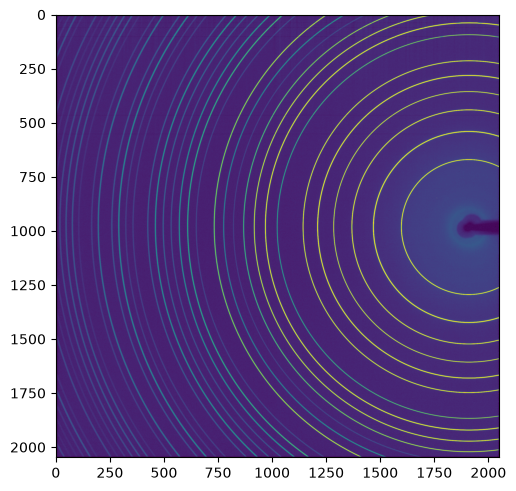

In [3]:
# We can display the LaB6/img.tiff as below.
plt.figure()
plt.imshow(fabio.open('LaB6/img.tiff').data,vmin=0,vmax=100)

In order to radially integrate this 2D image, we need to use [pyFAI](https://pyfai.readthedocs.io/en/stable/).

Please refer to resources below about pyFAI usage.

* https://www.youtube.com/watch?v=hqp0UyvepXk&ab_channel=ESRFsynchrotron
* https://github.com/MehmetTopsakal/pySULI/blob/main/notebooks/003_learn_pyFAI.ipynb


We have provided a poni file `geometry.poni` in the working directory. It is basically a text file with the information below. Please refer to  pyFAI documentation about the meaning of poni file.

<ul>
# Nota: C-Order, 1 refers to the Y axis, 2 to the X axis<br>
# Calibration done at Mon Apr  8 17:18:53 2024<br>
poni_version: 2.1<br>
Detector: Perkin\
Detector_config: {"pixel1": 0.0002, "pixel2": 0.0002, "orientation": 3}<br>
Distance: 1.4280248574010523<br>
Poni1: 0.23404917788488025<br>
Poni2: 0.3766844373109601<br>
Rot1: -0.0037624252170773112<br>
Rot2: -0.026178177480714798<br>
Rot3: -7.996604624242792e-10<br>
Wavelength: 1.814e-11<br>
</ul>

In the 2D image above, there are some areas such as beamstop shadow, bad pixels and the edges of the detector that we need to mask. You can use `pyFAI-drawmask` executable that comes with pyFAI package. See https://pyfai.readthedocs.io/en/v2023.1/man/pyFAI-drawmask.html We have provided a mask file as displayed below.

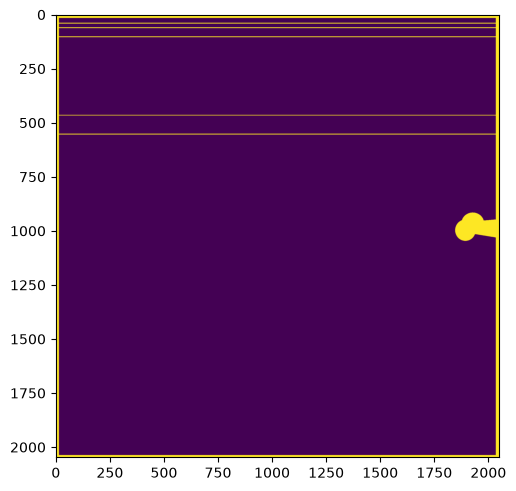

In [4]:
plt.figure()
plt.imshow(fabio.open('mask.edf').data)

In [5]:
# We believe, we made it quite straightforward to read and integrate a given 2D detector tiff file using easyXRD.

# As usual, we need to initialize exrd object.
sample = exrd()

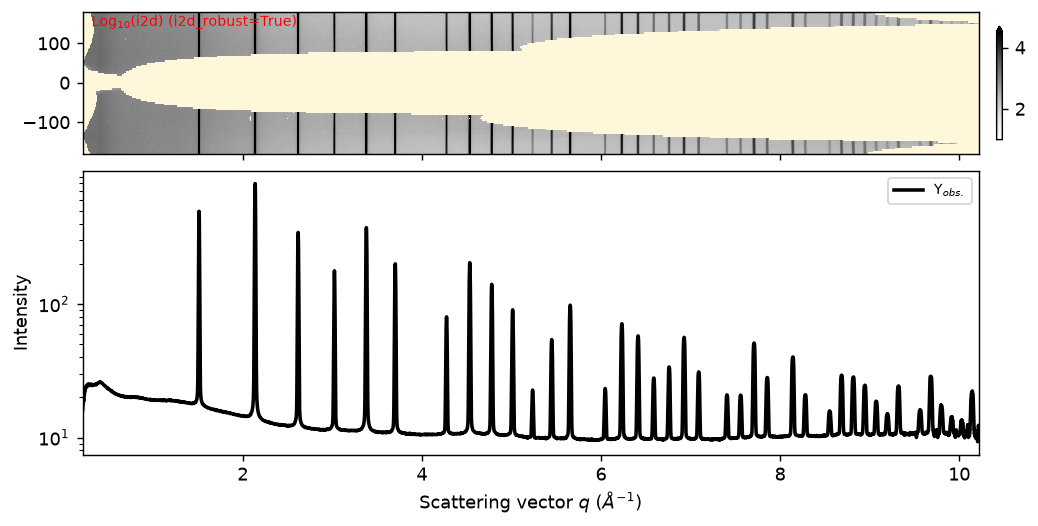

In [6]:
sample.load_xrd_data(
    from_tiff_file='LaB6/img.tiff', # image file
    poni_file='geometry.poni', # poni file you can get from pyFAI-calib2.
    mask_file='mask.edf', # maks file you can get from pyFAI-drawmask.
    )

# The bottom subplot in the figure below is same as 1D profile we loaded in previous notebook, 01_basic.ipynb.
# The new information is 2D image (i2d) in the upper subplot. It is basically reorganized data of LaB6/img.tiff
# we plotted in the first figure above. XRD community calls it as "cake". The yellow-ish parts are masked regions.
# If we average this image in y-direction, we get the 1D profile that we call as "i1d".


 ⏩--1st refinement with LeBail is completed. Rwp/GoF is 28.829/1.207 



 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 14.957/0.627 (was 28.829(-48.12%)/1.207(-48.09%✨))


 ✅--Cell parameters are refined. Rwp/GoF is now 11.001/0.461 (was 14.957(-26.45%)/0.627(-26.48%✨))


 ✅--Instrument parameter ['U'] is refined. Rwp/GoF is now 8.274/0.347 (was 11.001(-24.78%)/0.461(-24.78%✨))


 ✅--Instrument parameter ['V'] is refined. Rwp/GoF is now 7.967/0.334 (was 8.274(-3.71%)/0.347(-3.71%))


...

 ✅--Instrument parameter ['V'] is refined. Rwp/GoF is now 6.112/0.256 (was 6.160(-0.78%)/0.258(-0.78%❗))


 ✅--Instrument parameter ['W'] is refined. Rwp/GoF is now 6.090/0.255 (was 6.112(-0.36%)/0.256(-0.36%❗))


 ✅--Instrument parameter ['Zero'] is refined. Rwp/GoF is now 6.084/0.255 (was 6.090(-0.10%)/0.255(-0.10%❗))


 ✅--Cell parameters are refined. Rwp/GoF is now 6.088/0.255 (was 6.084(0.06%)/0.255(0.06%❗))


 ✅--Background with 15 coeffs is refined. Rwp/GoF is now 5.843/0.245 (was 6.088(-4.02%)/0.255(-3.95%))


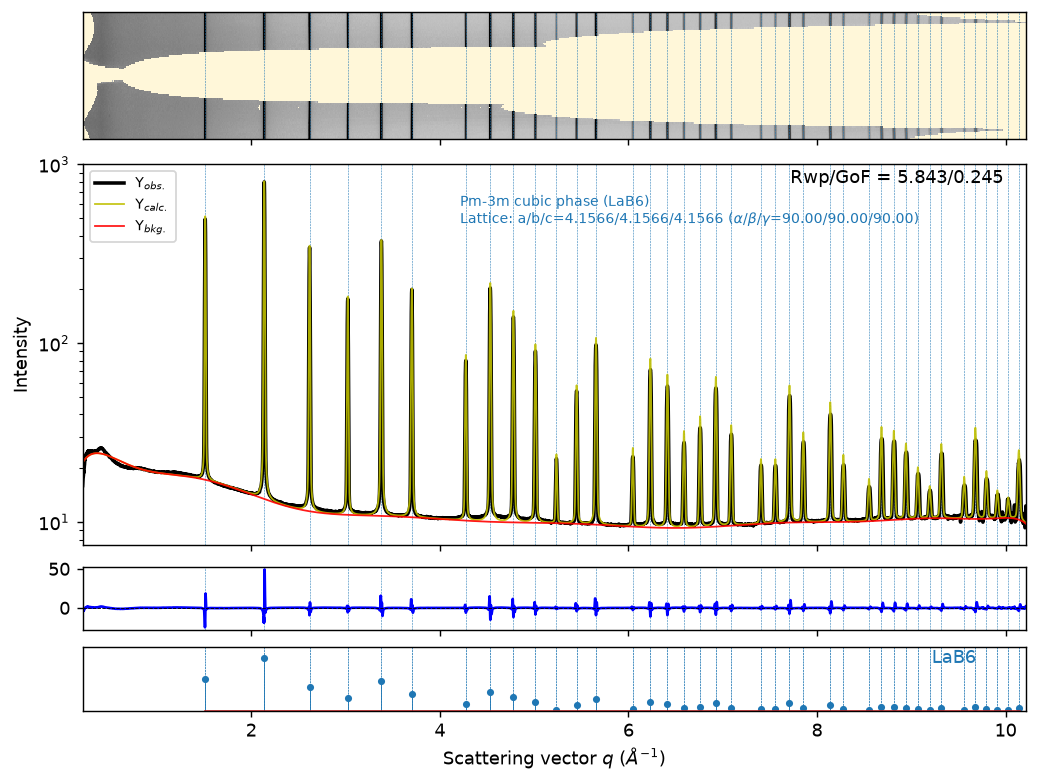

In [7]:
# Now we can refine this sample information using easyXRD as we did in previous notebook.

sample.load_phases(
    [{"cif": "LaB6/LaB6_structure_from_MaterialsProject.cif", "label": "LaB6"}], plot=False
)
sample.setup_gsas2_refiner(plot=False)

sample.refine_background(plot=False)
sample.refine_cell_parameters(plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["U"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["V"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["W"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["Zero"], plot=False)

sample.refine_background(plot=False)
sample.refine_cell_parameters(plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["U"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["V"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["W"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["Zero"], plot=False)

sample.refine_background(plot=False)
sample.refine_cell_parameters(plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["U"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["V"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["W"], plot=False)
sample.refine_instrument_parameters(inst_pars_to_refine=["Zero"], plot=False)

# We can re-refine background since we improved instrument parameters in previous steps
sample.refine_cell_parameters(plot=False)

# We can re-refine background with higher number of coefficients
sample.refine_background(num_coeffs=15, plot=False)

sample.plot()

If you zoom in to high-q regions in the above plot you will see that the Yobs. is getting noisy. The reason is clear \
in the 12d information. Because, those regions correspponds to the edge of the detector and less pixels contribute to \
the data making the i1d plot noisy. Therefore, we can exlude those regions and the low q areas corresponding to beam-stop \
with the `radial_range=[1, 9.5]` keyword as we did in previous notebook `01_basic.ipynb`. We believe, this is a strength \
of `easyXRD`. We can see the raw data alongside 1d profile. To the best of our knowledge, no other programs such as
`TOPAS, GSAS-II or FullProf...` has this functionality.

In [8]:
# Now we can export refined as LaB6 GSAS-II project file (gpx).
sample.export_gpx_to('LaB6.gpx')

<a id="ceo2-refinement"></a>
## 3. CeO2: Standard Refinement (Le Bail, Size Broadening & Rietveld)


Now we can continue with `CeO2` NIST powder (https://tsapps.nist.gov/srmext/certificates/674b.pdf ) XRD data which was collected in same beamline conditions.


In [9]:
# As usual, we need to initialize exrd object.
sample = exrd()

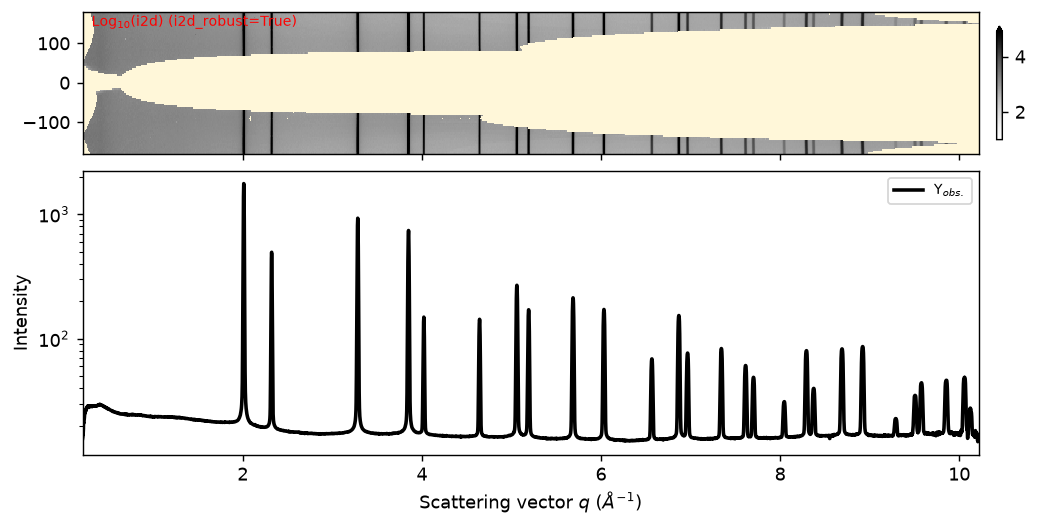

In [10]:
sample.load_xrd_data(
    from_tiff_file='CeO2/img.tiff', # image file
    poni_file='geometry.poni', # poni file you can get from pyFAI-calib2.
    mask_file='mask.edf', # maks file you can get from pyFAI-drawmask.
    )

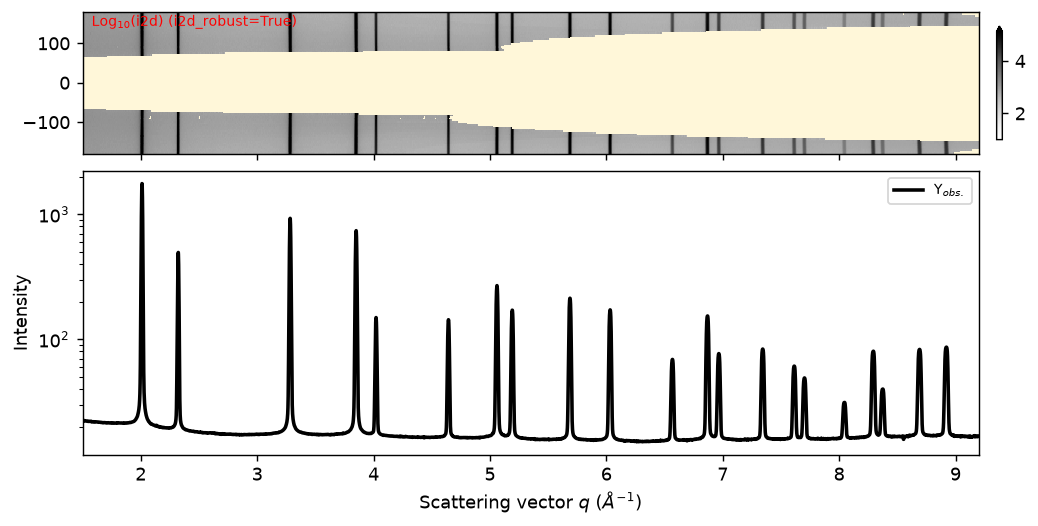

In [11]:
# Based on plot above, it would be good to limit q_range from 1.5 to 9.2

sample.load_xrd_data(
    from_tiff_file='CeO2/img.tiff', # image file
    poni_file='geometry.poni', # poni file you can get from pyFAI-calib2.
    mask_file='mask.edf', # maks file you can get from pyFAI-drawmask.
    radial_range=[1.5, 9.2]
    )

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

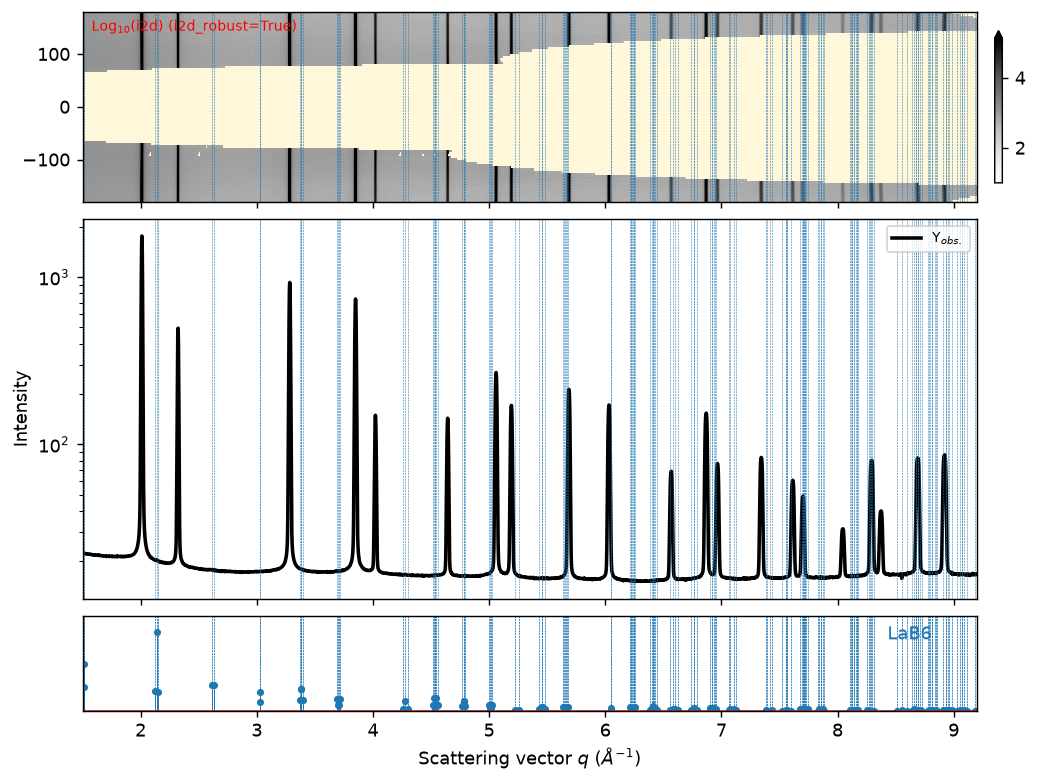

In [12]:
# Try LaB6 Materials Project ID (mp-2680) against CeO2 experimental XRD
import os

mp_api_key = os.environ.get("MP_API_KEY")
if not mp_api_key and "google.colab" in sys.modules:
    try:
        from google.colab import userdata
        mp_api_key = userdata.get("MP_API_KEY")
    except Exception:
        mp_api_key = None

sample.load_phases(
    [{"mp_id": "mp-2680", "label": "LaB6"}],
    mp_rester_api_key=mp_api_key,
    plot=True,
)

# Obviously, the LaB6 phase does not match the observed peaks of CeO2.


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

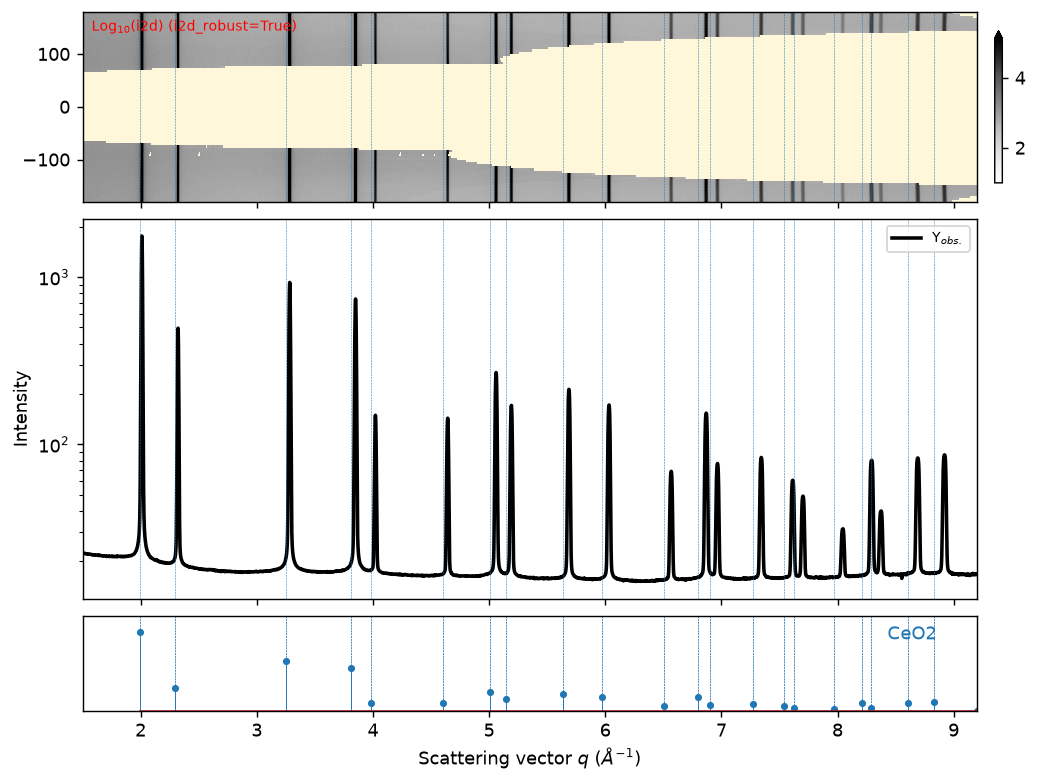

In [13]:
# Load the correct structure for CeO2 from Materials Project (mp-20194)
# Reference: https://next-gen.materialsproject.org/materials/mp-20194

sample.load_phases(
    [{"mp_id": "mp-20194", "label": "CeO2"}],
    mp_rester_api_key=mp_api_key,
    plot=True,
)

# This structure matches the peak positions well at low q, but slight mismatch
# occurs at higher q due to small differences in the DFT-calculated lattice constant.
# easyXRD refinement will optimize the unit cell lattice constant to match experiment.



 ⏩--1st refinement with LeBail is completed. Rwp/GoF is 61.142/0.779 



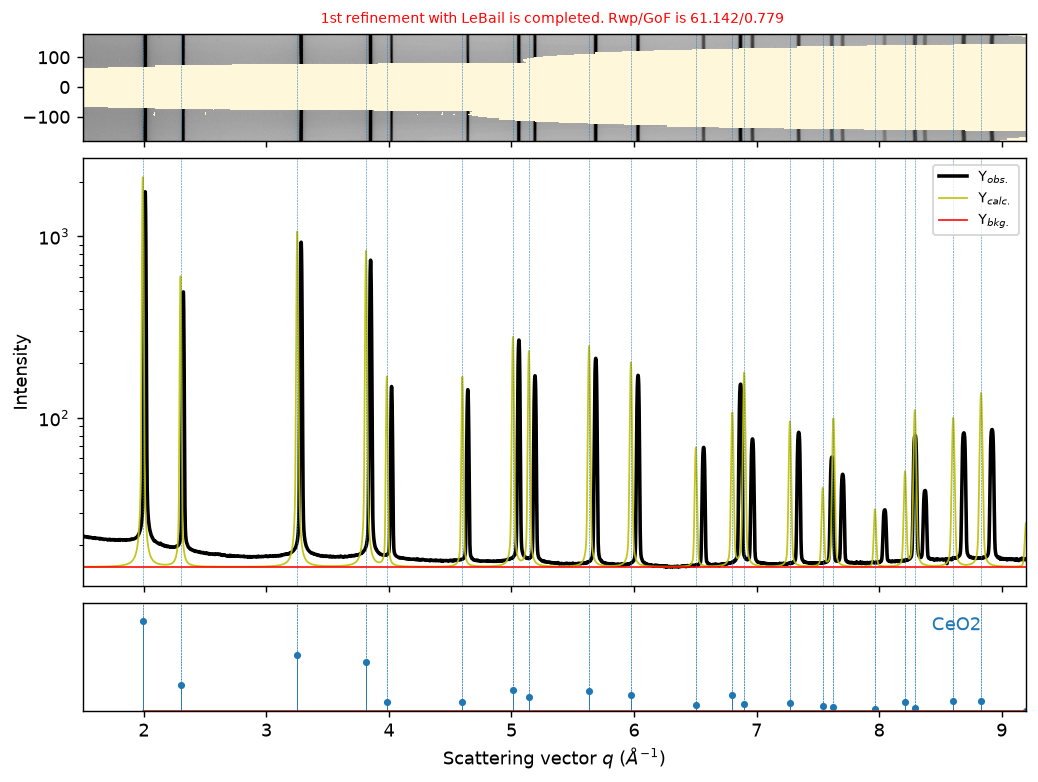

In [14]:
# Here we proceed with refinement.
# Since we refined the instrument parameters previously on LaB6, ideally we shouldn't refine it for CeO2.
# We can use instprm_from_gpx keyword in setup_gsas2_refiner to use refined instrument parameters.

sample.setup_gsas2_refiner(plot=True, normalize=True, instprm_from_gpx='LaB6.gpx')

# As a result, refinement is very poor. Because of the wrong initial lattice parameters.

 ✅--Cell parameters are refined. Rwp/GoF is now 61.108/0.779 (was 61.142(-0.05%)/0.779(-0.05%❗))


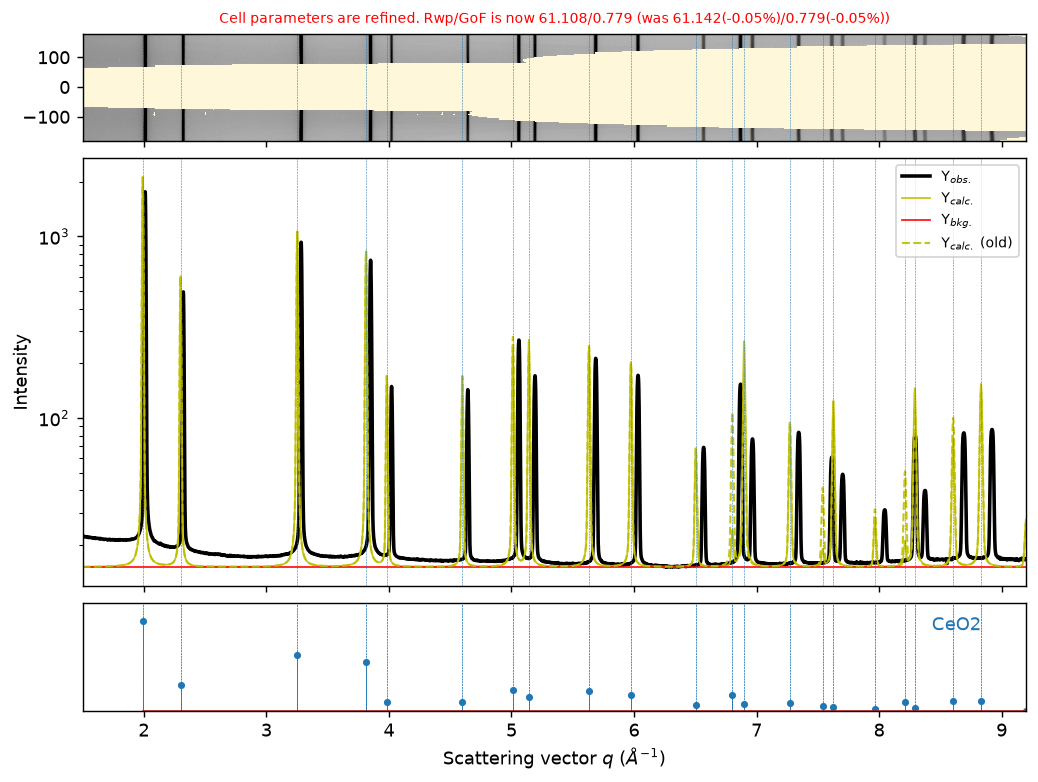

In [15]:
# Let's refine the cell parameters.

sample.refine_cell_parameters(plot=True)

# Obviously, the cell refinement was not able to find correct lattice, hence it is still a poor fit.

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]


 ⏩--1st refinement with LeBail is completed. Rwp/GoF is now 17.112/0.218 (was 61.142(-72.01%)/0.779(-72.01%✨)) 



 ✅--Cell parameters are refined. Rwp/GoF is now 11.476/0.146 (was 17.112(-32.94%)/0.218(-32.93%✨))


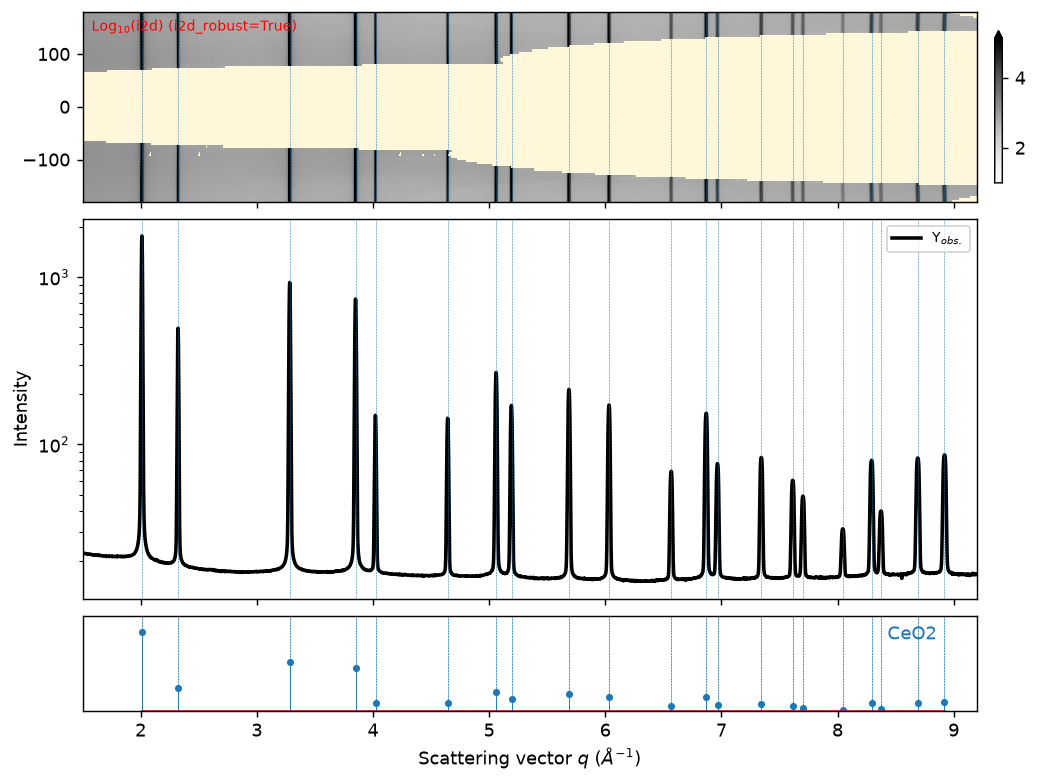

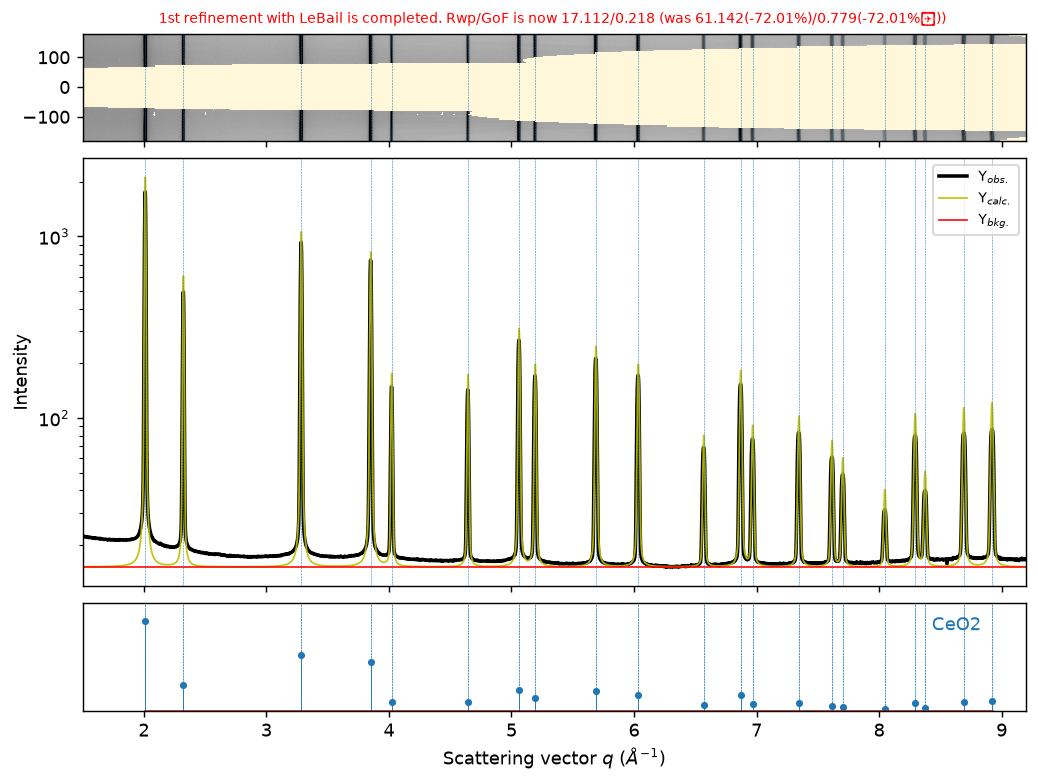

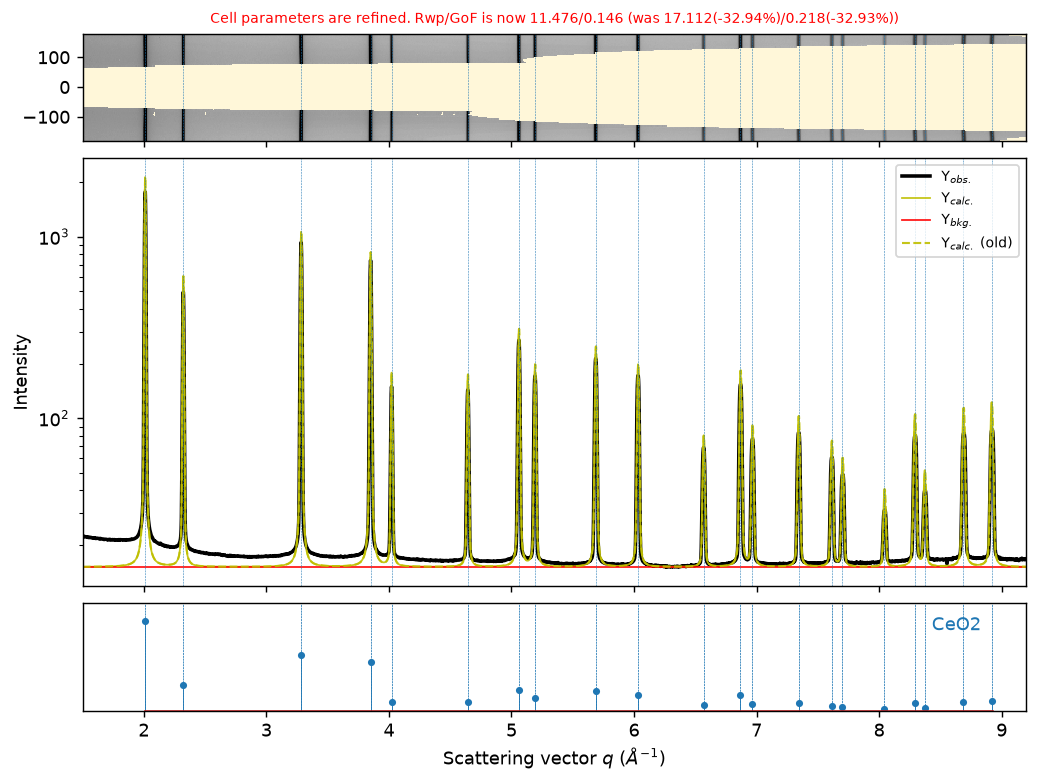

In [16]:
# Therefore, we can "help" refinement by manually changing the lattice parameters.
# For this, we need to use "scale" parameter in phases dict.

sample.load_phases(
    [{"mp_id": "mp-20194", "label": "CeO2", "scale": 0.99}],
    plot=True,
    )


sample.setup_gsas2_refiner(plot=True, normalize=True, instprm_from_gpx='LaB6.gpx')
sample.refine_cell_parameters(plot=True)

 ✅--Background with 5 coeffs is refined. Rwp/GoF is now 7.169/0.091 (was 11.476(-37.53%)/0.146(-37.51%✨))


 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 6.996/0.089 (was 7.169(-2.42%)/0.091(-2.39%))


 ✅--Background with 15 coeffs is refined. Rwp/GoF is now 6.988/0.089 (was 6.996(-0.11%)/0.089(-0.08%❗))


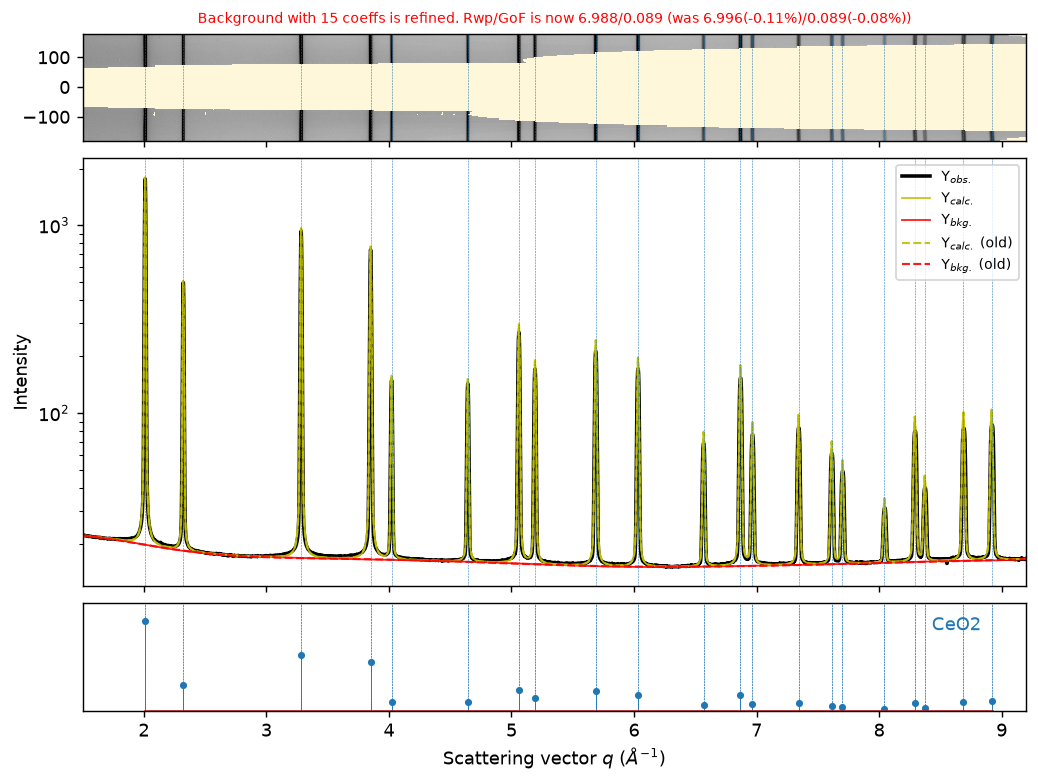

In [17]:
# Here we refine the background by gradually increasing the number of coefficients.

sample.refine_background(num_coeffs=5,plot=False)
sample.refine_background(num_coeffs=10,plot=False)
sample.refine_background(num_coeffs=15,plot=True)

 ✅--Size broadening of all phases are refined. Rwp/GoF is now 6.967/0.089 (was 6.988(-0.30%)/0.089(-0.39%❗))


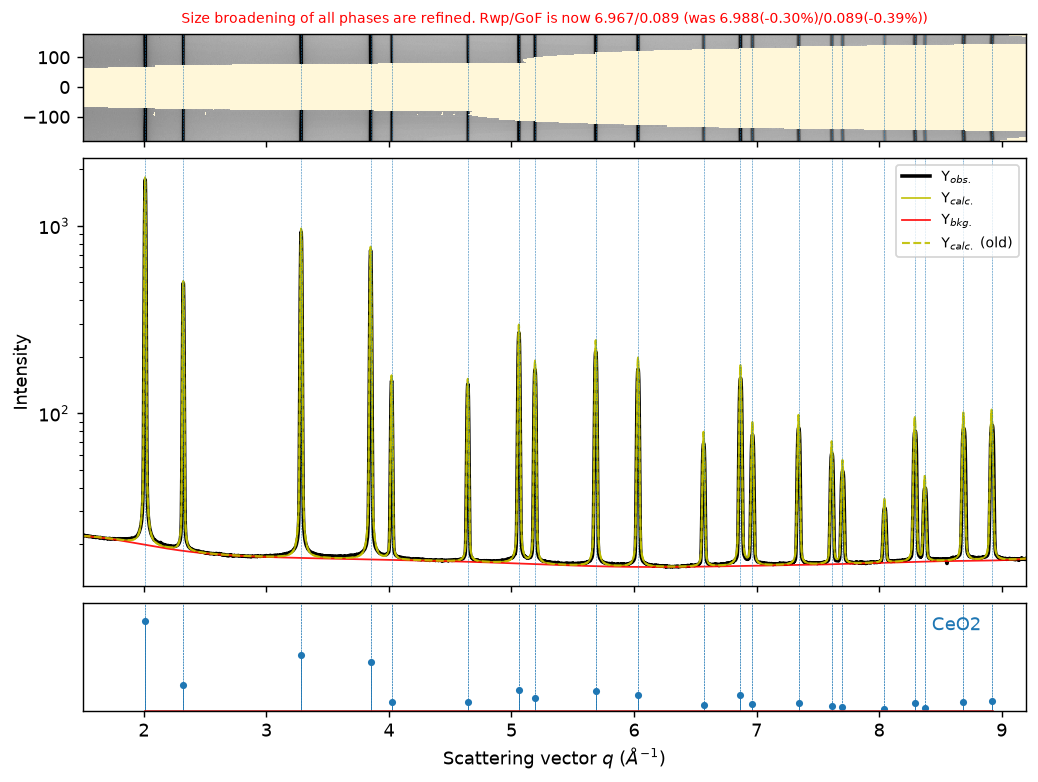

In [18]:
# Here we refine size broadening.

sample.refine_size_broadening(plot=True)

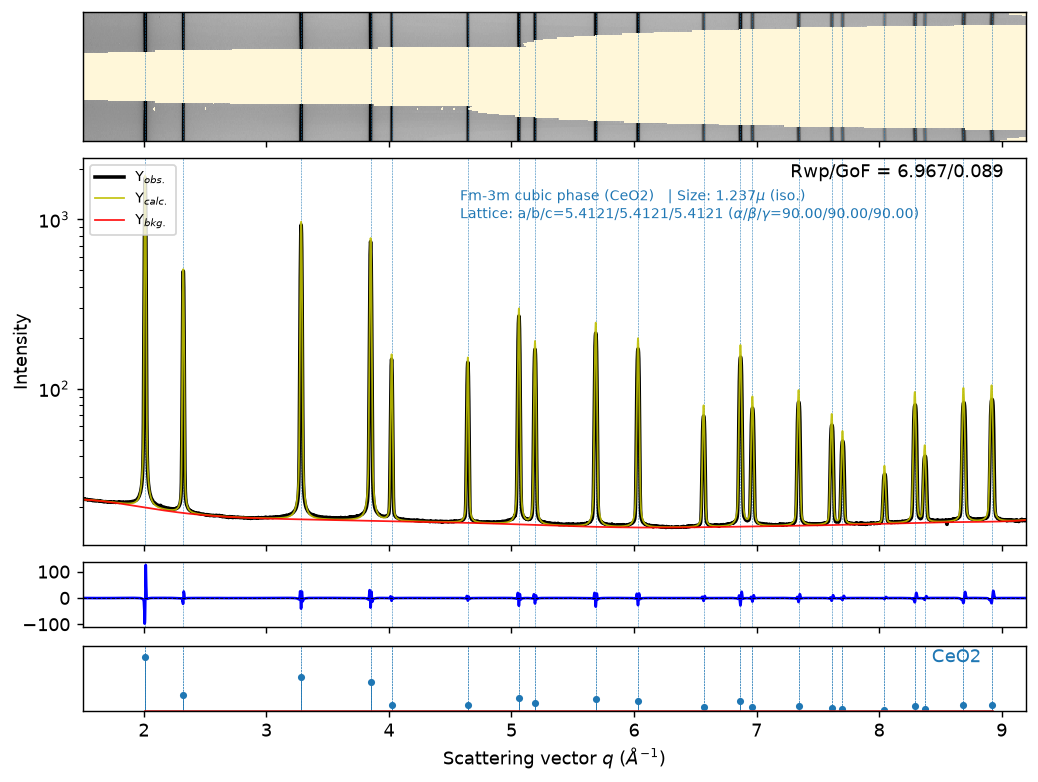

In [19]:
# This creates a final figure with LeBail refinement.

sample.plot()


 ✅--After setting LeBail refinement to False, Rwp/GoF is now 10.256/0.131 (was 6.967(47.19%)/0.089(47.19%❗))


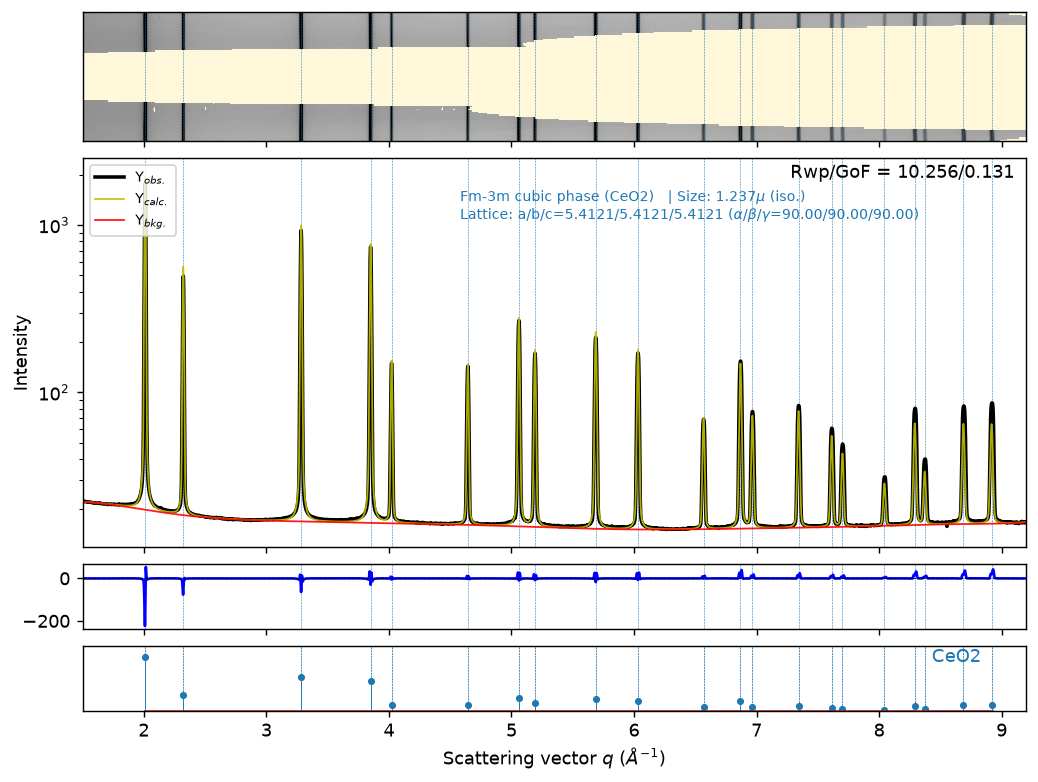

In [20]:
# Until now, we were doing Le-Bail refinements in which atom positions are not taken into consideration.
# We enable Rietveld by setting LeBail to false in GSAS settings.

sample.set_LeBail(to=False, refine=True, plot=False)
sample.plot()

# If you zoom in figure below, you will see the peak intensites got worse especially at high-q regions.

<a id="atom-properties"></a>
### Refining Atomic Site Properties ($U_{\text{iso}}$)

In Rietveld refinement, peak intensities are calculated directly from the crystal structure:

$$I_{hkl} \propto |F_{hkl}|^2 = \left| \sum_j f_j \cdot \text{occ}_j \cdot \exp\left( -8\pi^2 U_{\text{iso}, j} \frac{\sin^2\theta}{\lambda^2} \right) \cdot \exp(2\pi i (h x_j + k y_j + l z_j)) \right|^2$$

Here, $U_{\text{iso}}$ is the isotropic atomic displacement (Debye-Waller thermal) parameter. Thermal vibrations cause peak intensities to attenuate rapidly at higher diffraction angles ($q$). Refining $U_{\text{iso}}$ brings calculated and observed high-$q$ peak intensities into agreement.

As next step, we can refine atom properties. Below is the screenshot of the GSAS-II window of this sample.

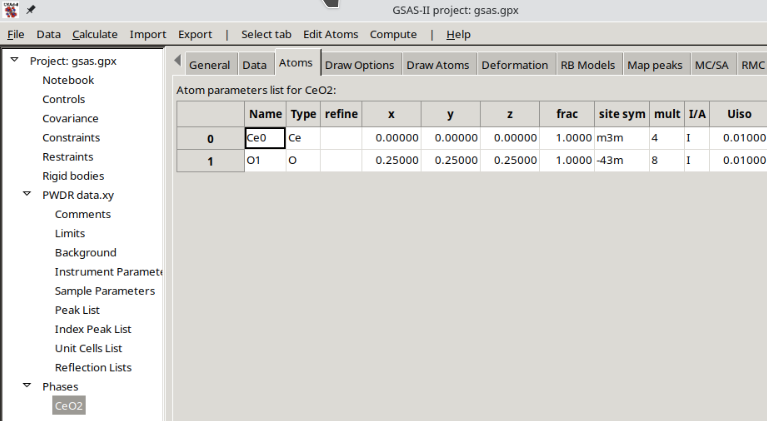

There is not much to refine in atomic positions. But we can refine the U parameters of Ce and O sites as shown in next cell.

 ✅--U property of Ce0 site of CeO2 phase is refined. Rwp/GoF is now 7.078/0.090 (was 10.256(-30.98%)/0.131(-30.97%✨))


 ✅--U property of O1 site of CeO2 phase is refined. Rwp/GoF is now 7.015/0.089 (was 7.078(-0.89%)/0.090(-0.89%❗))


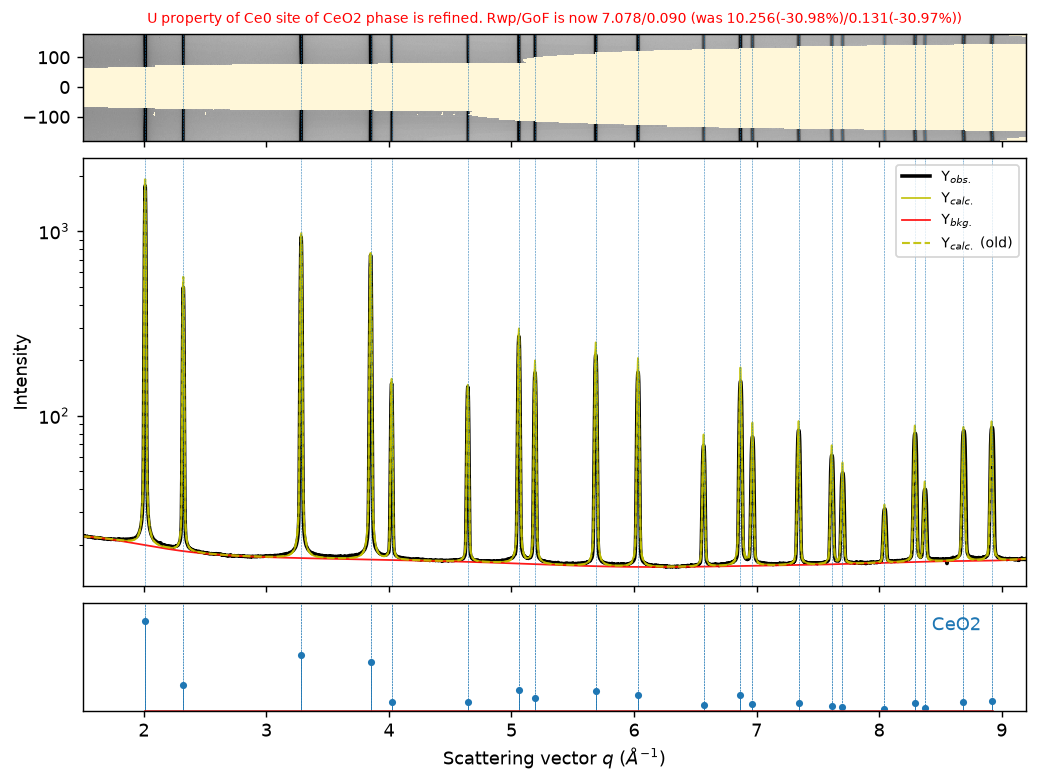

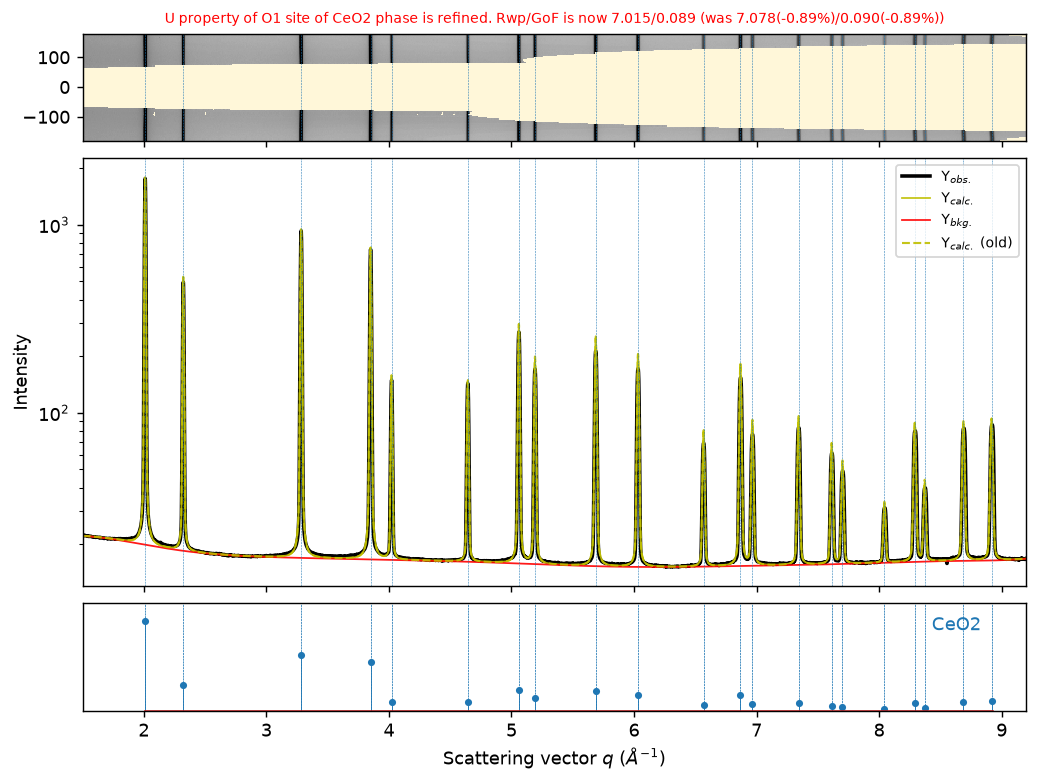

In [21]:
sample.refine_site_property(site_ind=0,refinement_flags='U',plot=True) # This refines Uiso of Ce site
sample.refine_site_property(site_ind=1,refinement_flags='U',plot=True) # This refines Uiso of O site

# Note the improvement at high q values and Rwp/GoF, especially for Ce site.

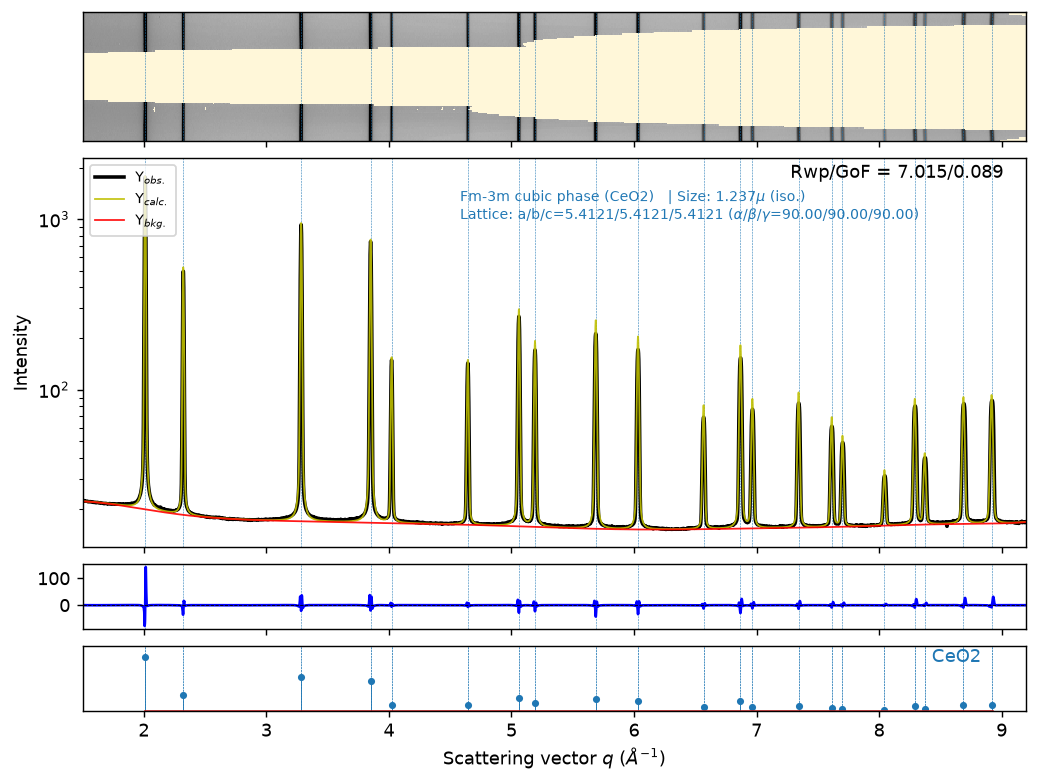

In [22]:
# This is the final plot

sample.plot()

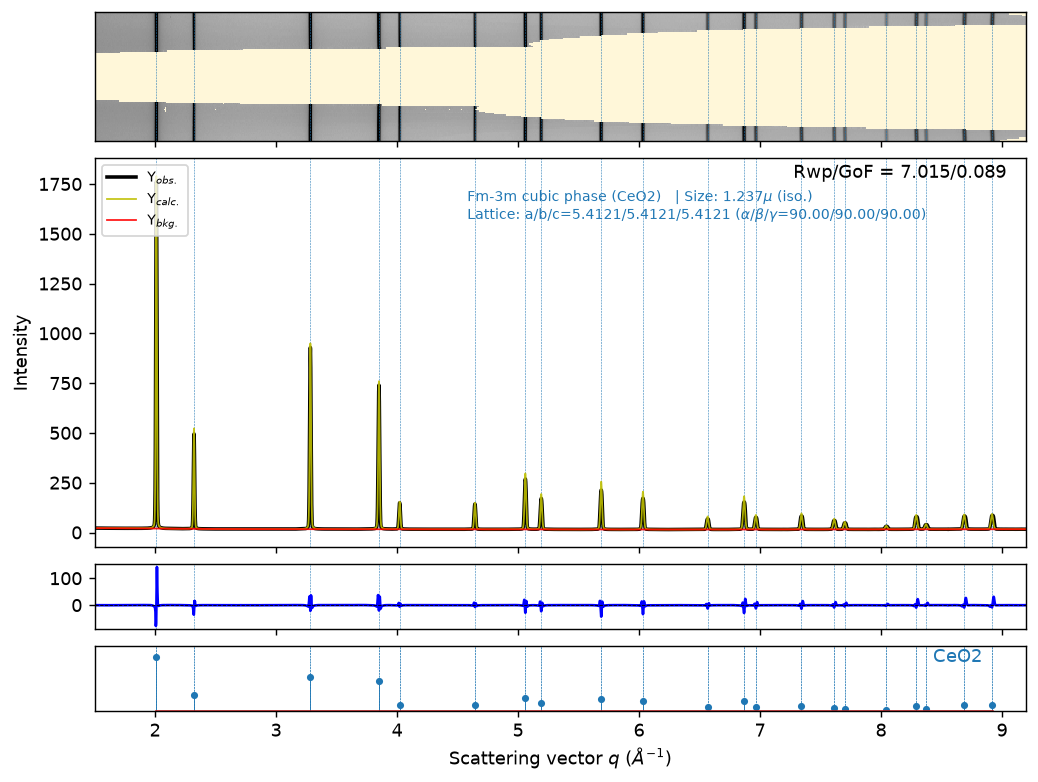

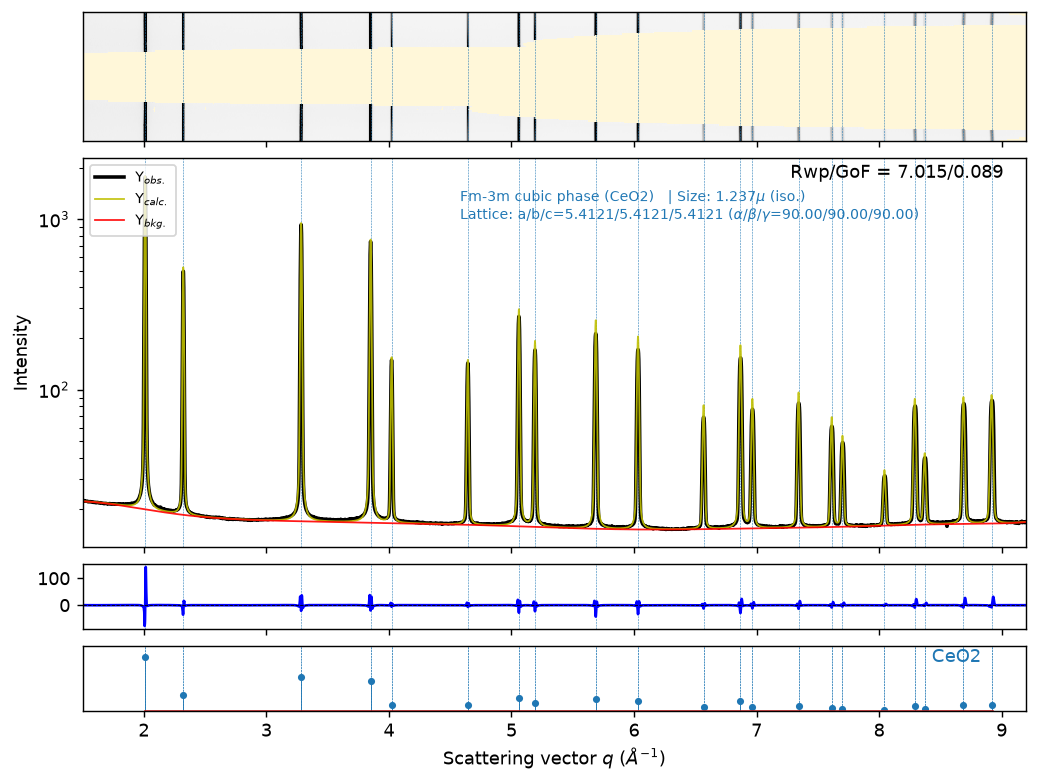

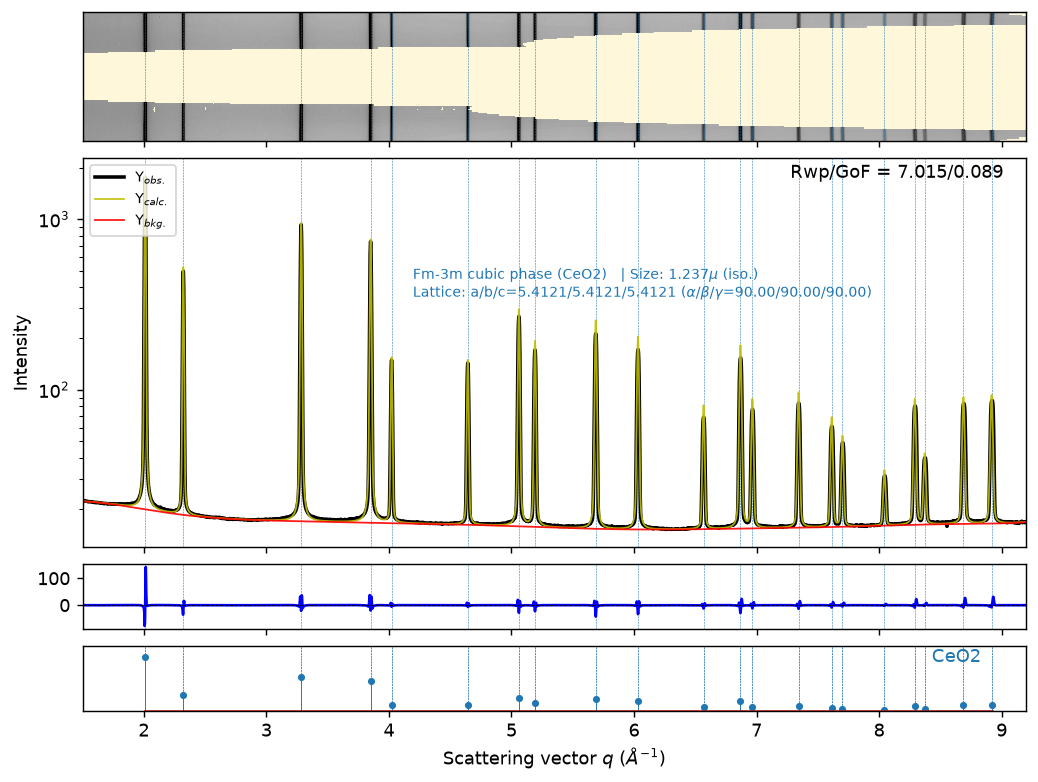

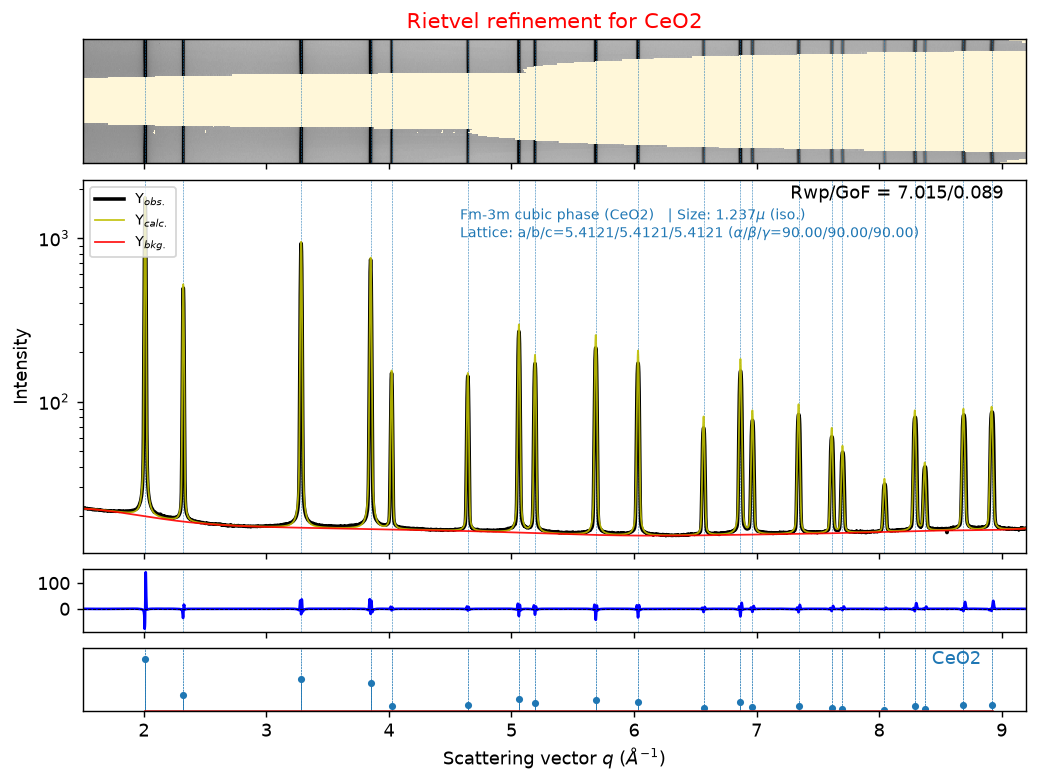

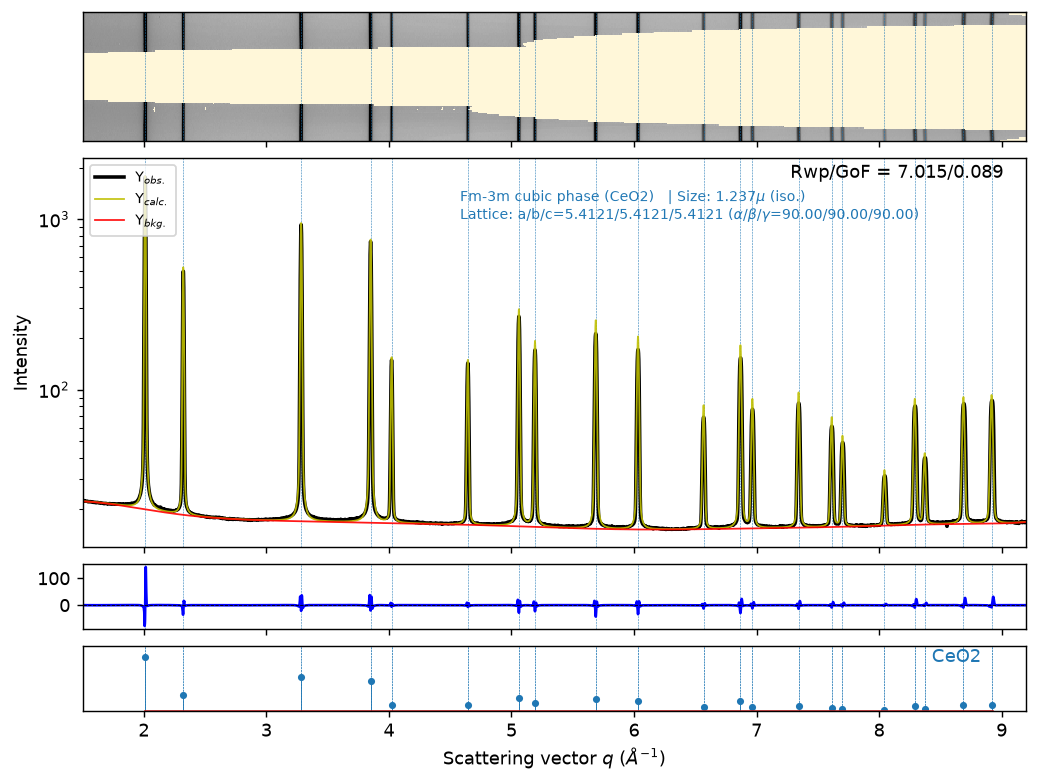

In [23]:
# The plot function here has more parameters. We can play with some of them here.

sample.plot(i1d_ylogscale=False) # Here we don't scale y-axis in log scale.
sample.plot(i2d_logscale=False) # Here we don't scale intensities in i2d in log scale.
sample.plot(site_str_x=0.5-0.15,site_str_y=0.8-0.2) # Here we move the info text inside the figure.
sample.plot(title='Rietvel refinement for CeO2') # Here we move the info text inside the figure.
sample.plot(export_fig_as='CeO2.pdf') # This creates a CeO2.pdf for high-resolution figures.
# See sample.plot? output for more details

<a id="multiphase"></a>
## 4. LaB6 + CeO2 Mix: Multi-Phase Analysis


Until now, we worked with pure LaB6 and CeO2 powders. Now we will work on a mix data of these materials.

Before that, we will read and integrate XRD of Kapton foil that was used during measurement of LaB6 and CeO2 powders.

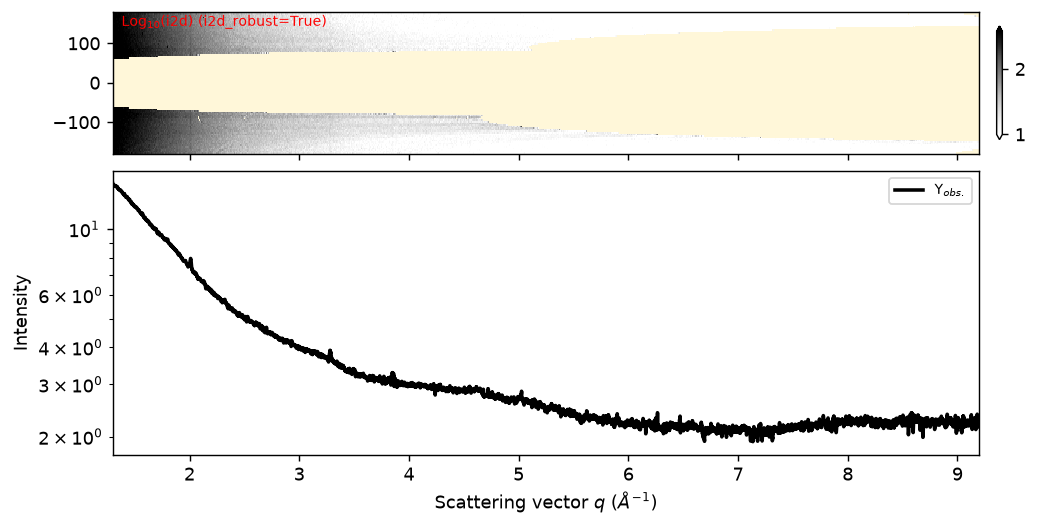

In [24]:
bkg = exrd()

bkg.load_xrd_data(
    from_tiff_file='Kapton/img.tiff',
    poni_file='geometry.poni',
    mask_file='mask.edf',
    radial_range=[1.3, 9.2]
    )

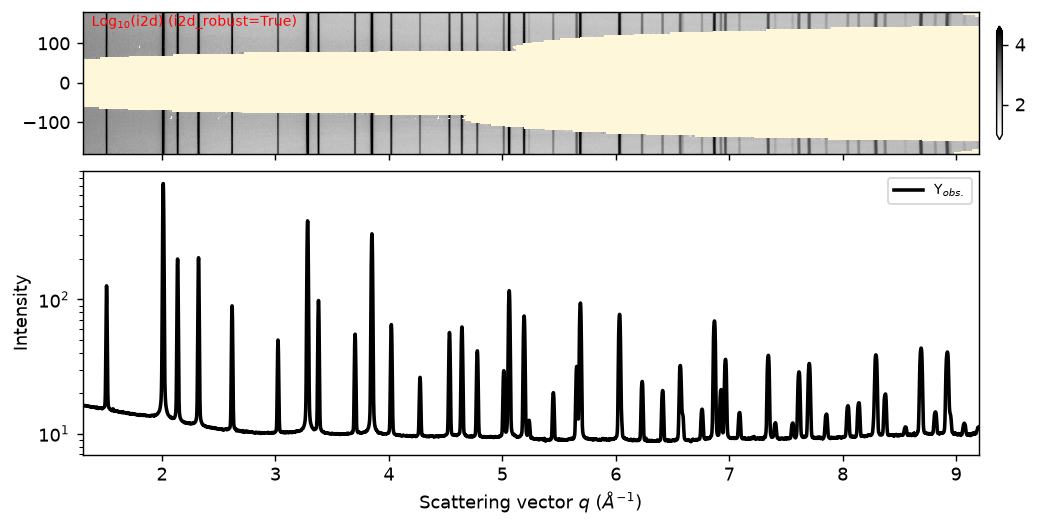

In [25]:
# Now load tiff image and integrate.
sample = exrd()

sample.load_xrd_data(
    from_tiff_file='LaB6_CeO2_mix/img.tiff',
    poni_file='geometry.poni',
    mask_file='mask.edf',
    radial_range=[1.3, 9.2]
    )

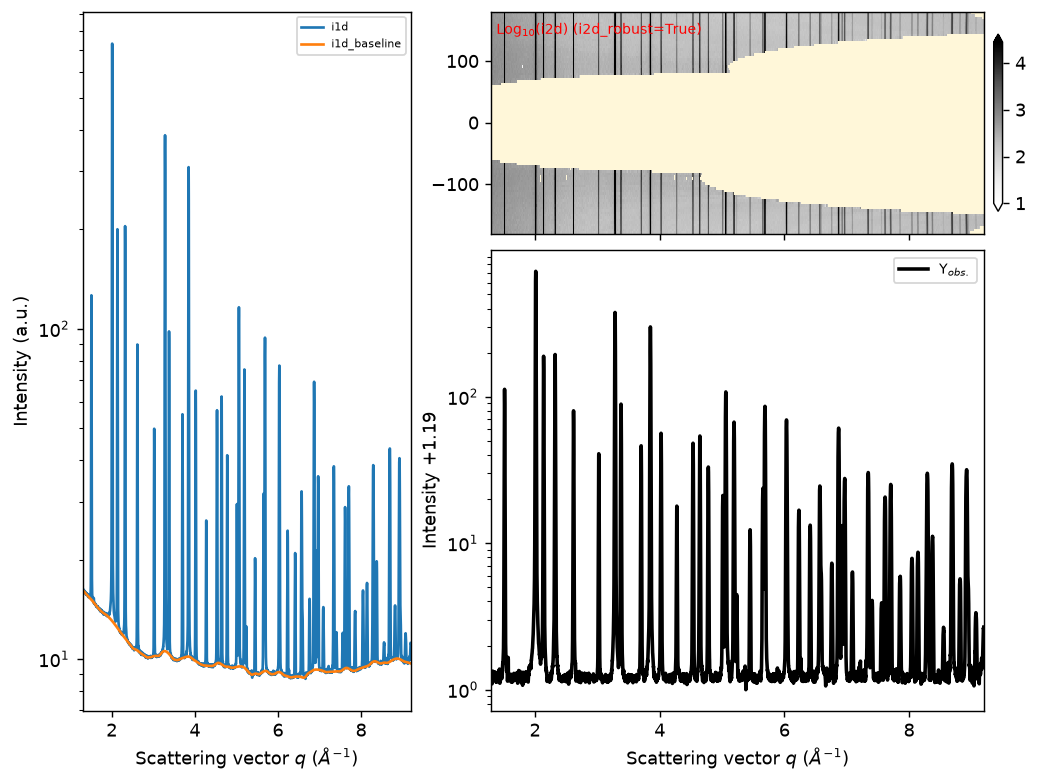

In [26]:
# Let's explore more details about get_baseline() feature of easyXRD.
#

sample.get_baseline()

# By default, it is using "iarpls (Improved Asymmetrically Reweighted Penalized Least Squares)"
# algorithm provided by pybaselines as in the note below:
# https://pybaselines.readthedocs.io/en/latest/algorithms/whittaker.html#iarpls-improved-asymmetrically-reweighted-penalized-least-squares

# It has a smoothing parameter, lam. Larger values will create smoother baselines. Default is 1e5.

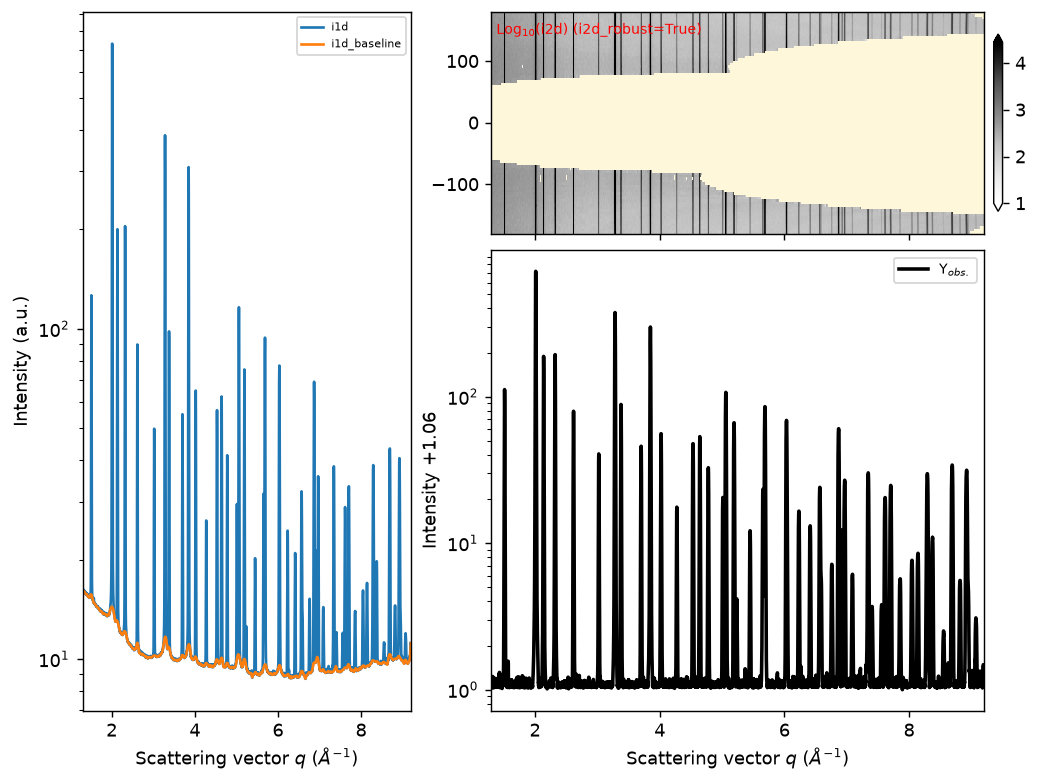

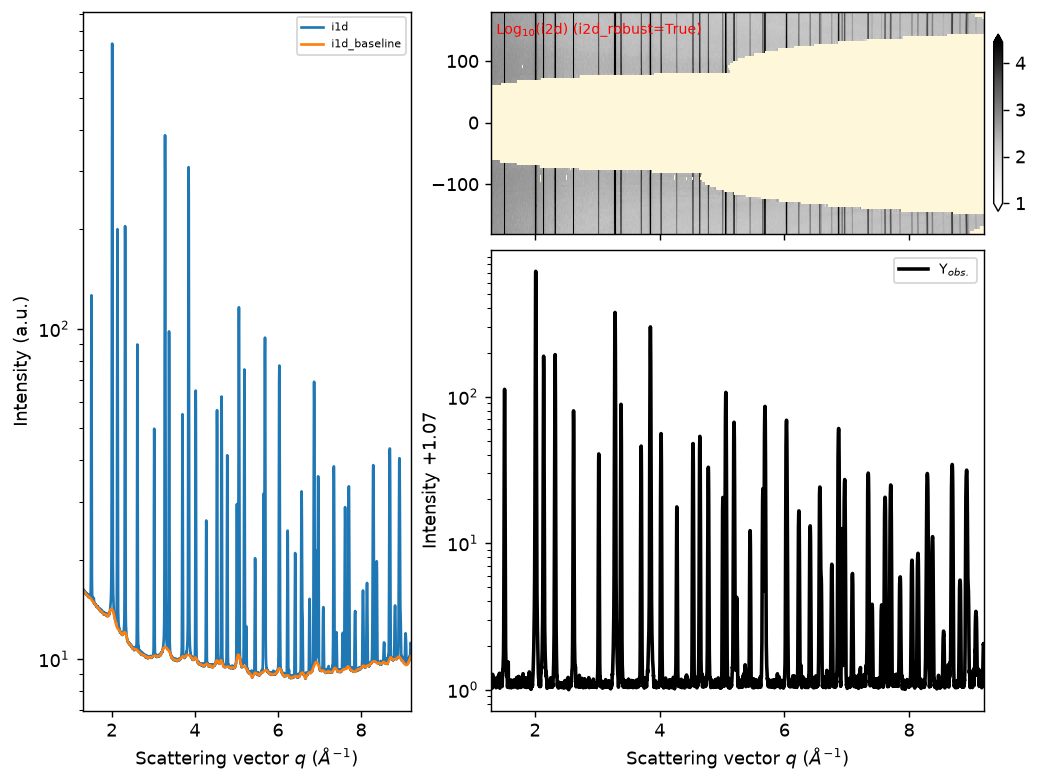

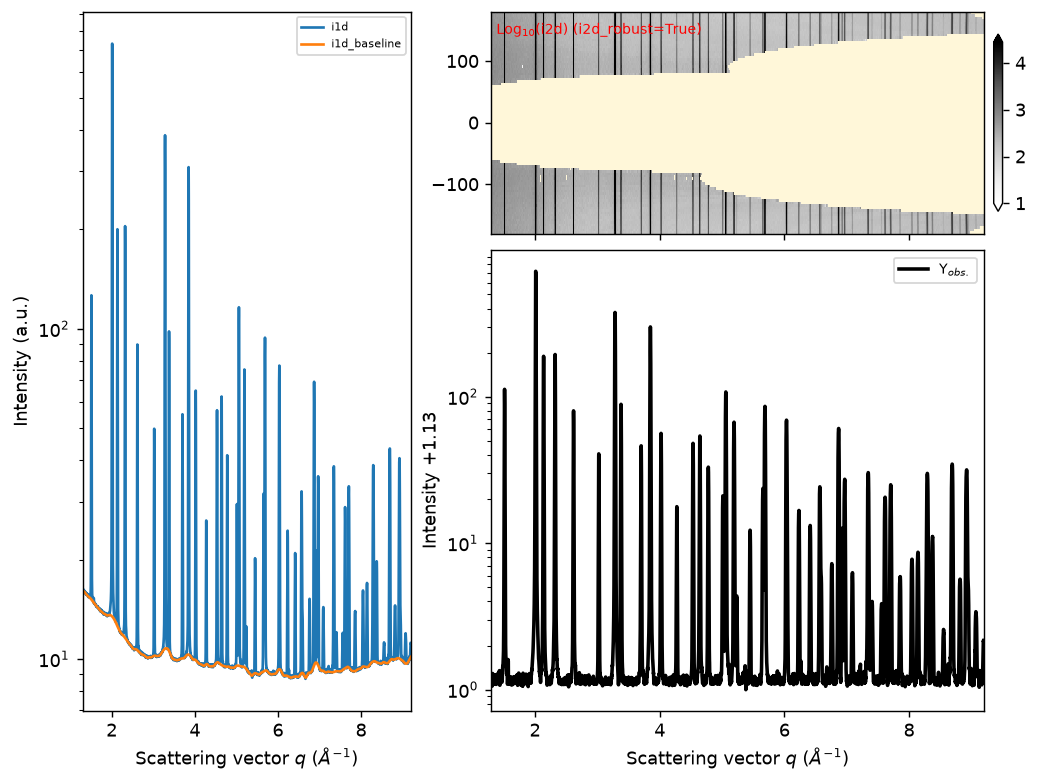

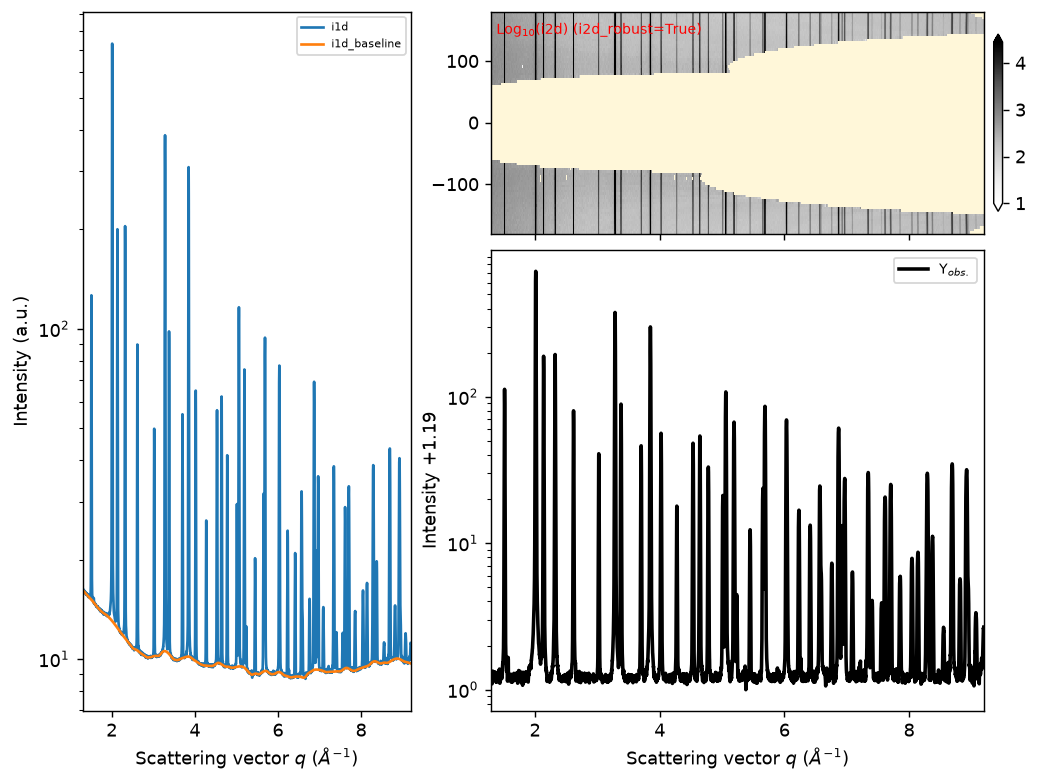

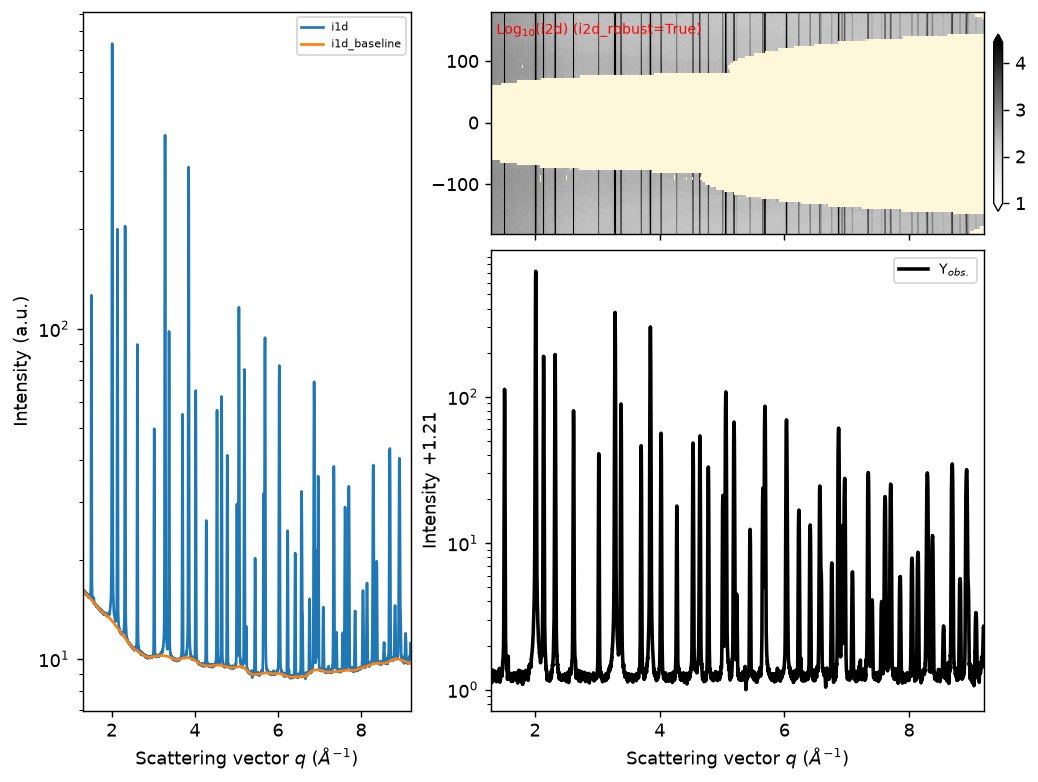

In [27]:
# We can easily vary iarpls_lam parameter from 1000 to 10000000 and see how it effects the estimated baseline.

sample.get_baseline(use_iarpls=True,iarpls_lam=1e2)
sample.get_baseline(use_iarpls=True,iarpls_lam=1e3)
sample.get_baseline(use_iarpls=True,iarpls_lam=1e4)
sample.get_baseline(use_iarpls=True,iarpls_lam=1e5)
sample.get_baseline(use_iarpls=True,iarpls_lam=1e6)

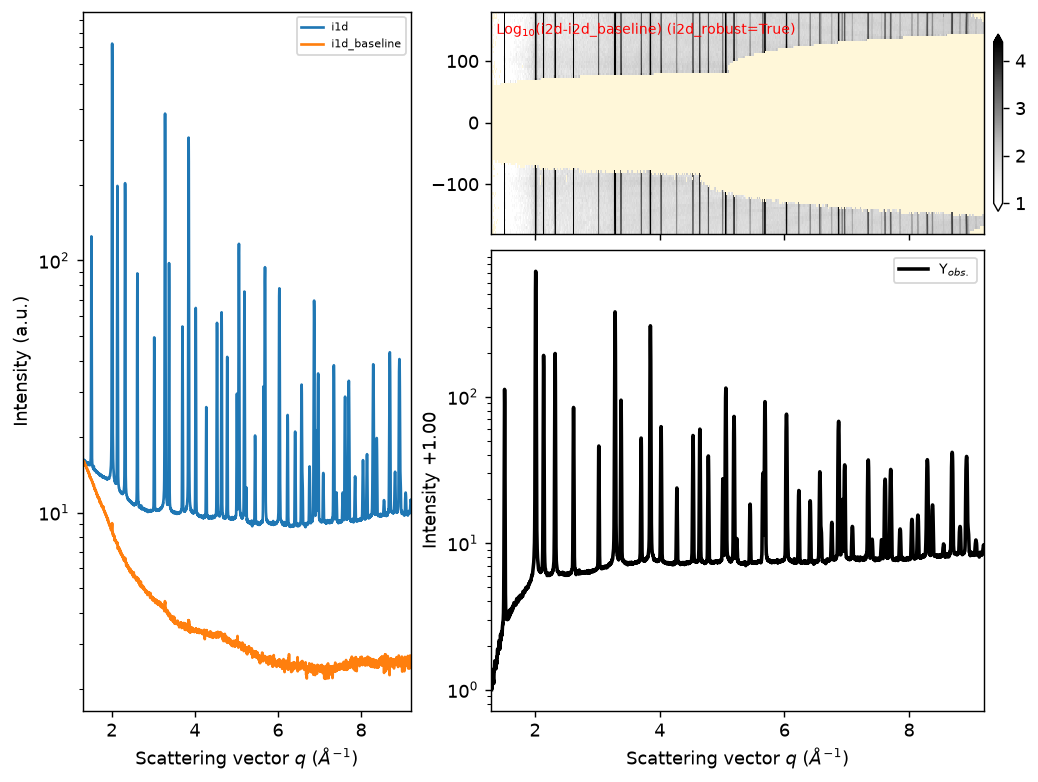

In [28]:
# Instead of estimating background with iarpls, we can use the Kapton data as shown below.
# The code automatically adjust the scaling parameter of input background until bbackground
# subtracted i1d doesn't have any negative values.

sample.get_baseline(input_bkg=bkg,use_iarpls=False)

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

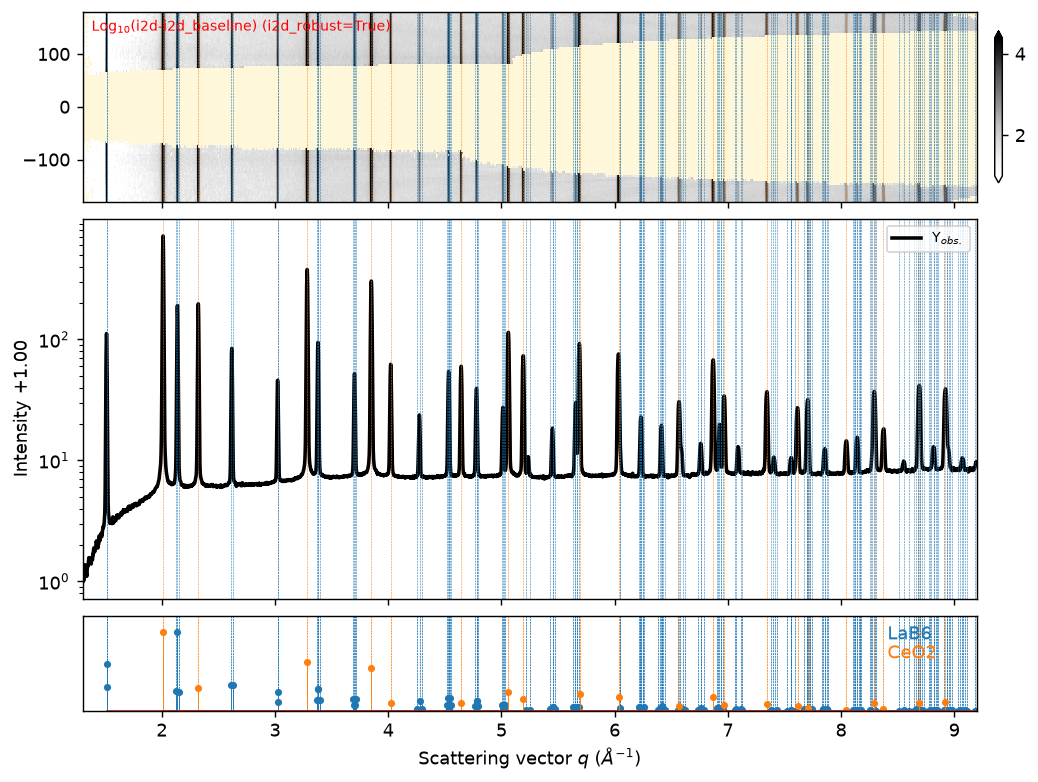

In [29]:
# Now we load phases from Materials Project

sample.load_phases(
    [
        {"mp_id": "mp-2680", "label": "LaB6",},
        {"mp_id": "mp-20194", "label": "CeO2", "scale": 0.99},
     ],
    plot=True,
    )


 ⏩--1st refinement with LeBail is completed. Rwp/GoF is 38.329/0.623 



 ✅--Background with 5 coeffs is refined. Rwp/GoF is now 9.446/0.154 (was 38.329(-75.35%)/0.623(-75.35%✨))


 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 9.425/0.153 (was 9.446(-0.22%)/0.154(-0.19%❗))


 ✅--Background with 15 coeffs is refined. Rwp/GoF is now 9.408/0.153 (was 9.425(-0.19%)/0.153(-0.16%❗))


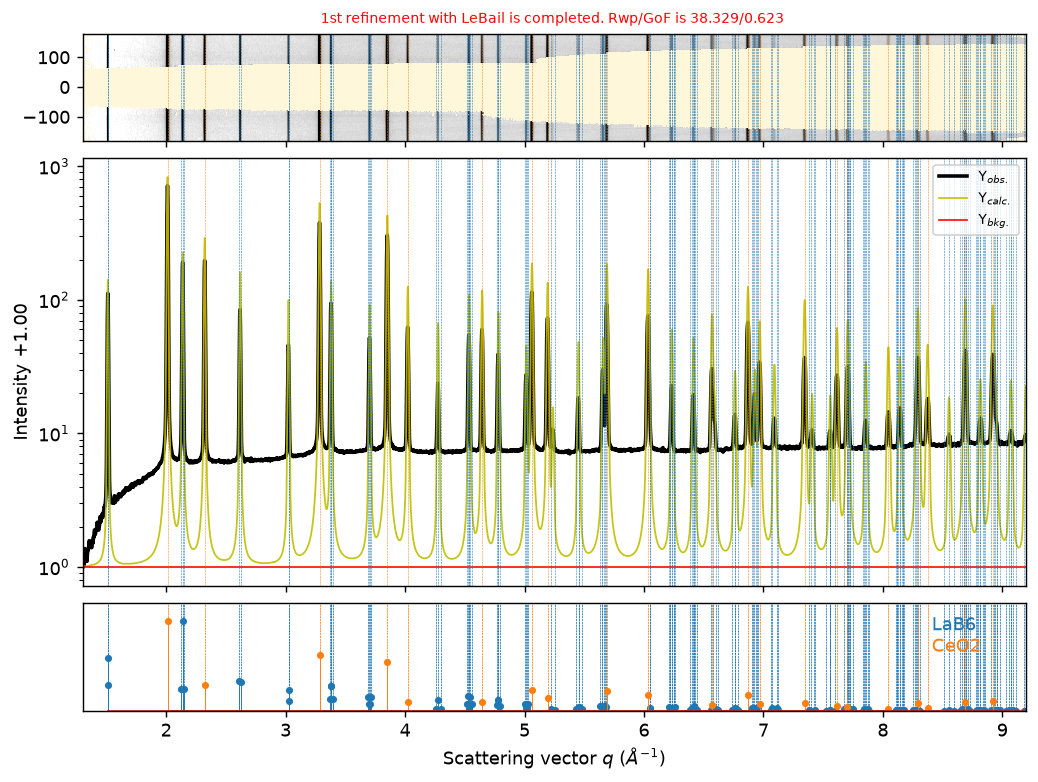

In [30]:
sample.setup_gsas2_refiner(plot=True, normalize=True, instprm_from_gpx='LaB6.gpx')
sample.refine_background(num_coeffs=5,plot=False)
sample.refine_background(num_coeffs=10,plot=False)
sample.refine_background(num_coeffs=15,plot=False)

 ✅--Cell parameters of all phases are refined. Rwp/GoF is now 6.175/0.100 (was 9.408(-34.36%)/0.153(-34.41%✨))


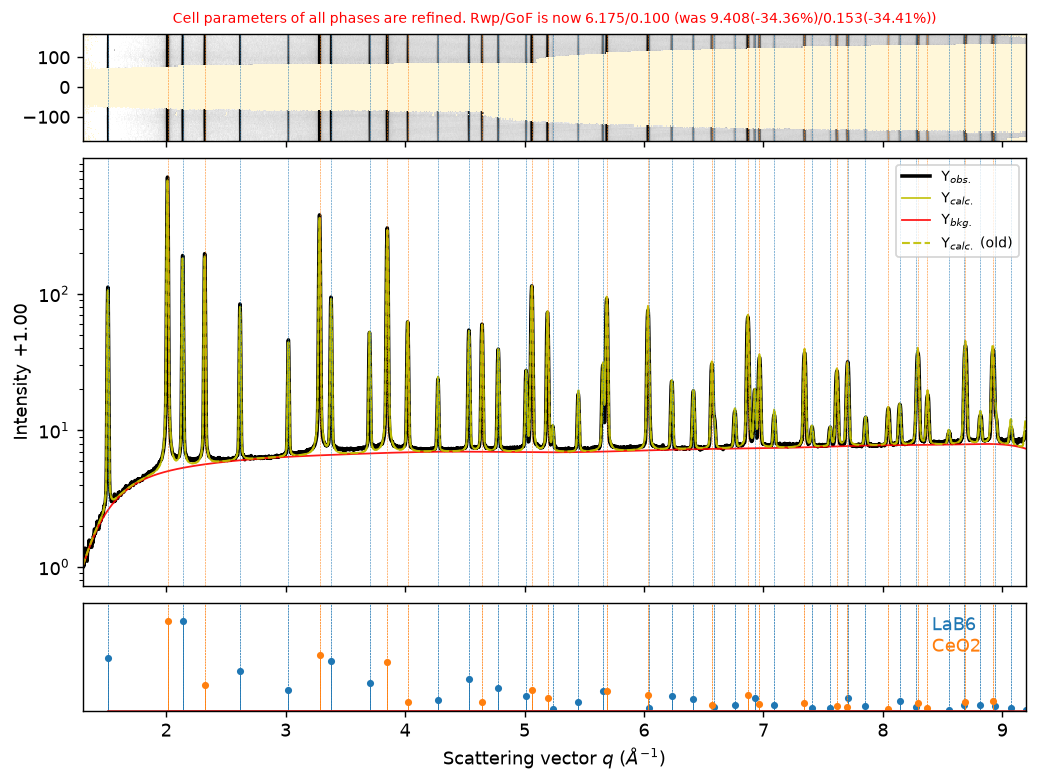

In [31]:
# We can refine cell parameters of LaB6 and CeO2 at the same time
sample.refine_cell_parameters(plot=True)

 ✅--Cell parameters of LaB6 phase are refined. Rwp/GoF is now 6.158/0.100 (was 6.175(-0.28%)/0.100(-0.29%❗))


 ✅--Cell parameters of CeO2 phase are refined. Rwp/GoF is now 6.144/0.100 (was 6.158(-0.23%)/0.100(-0.23%❗))


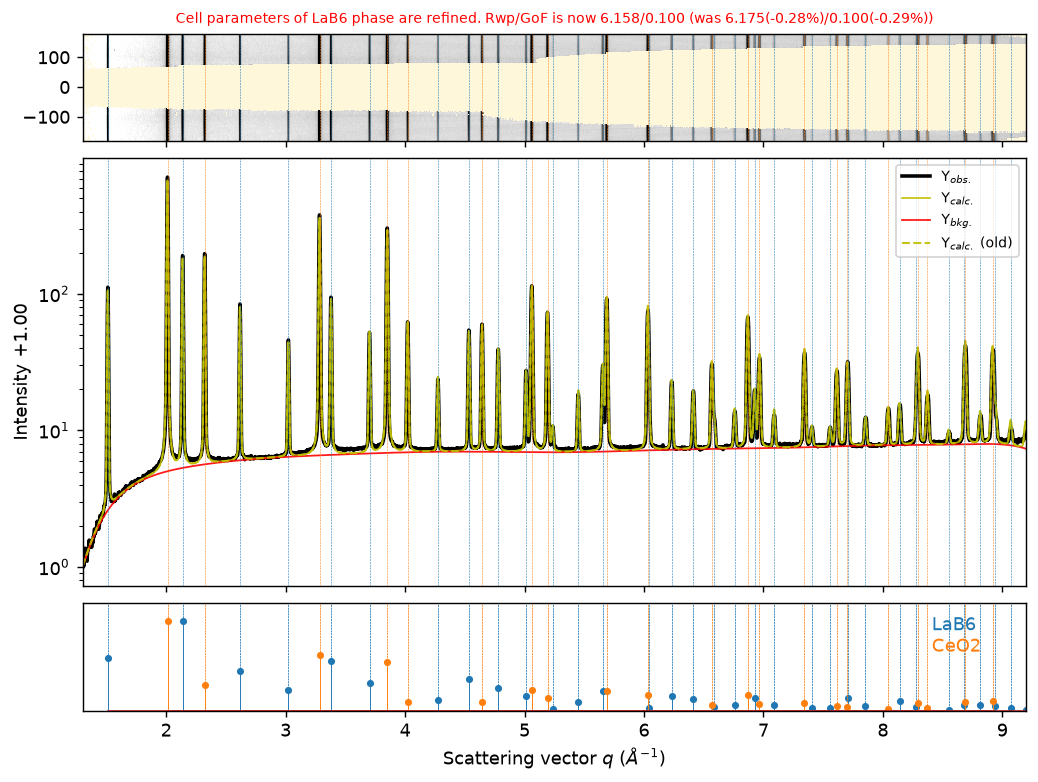

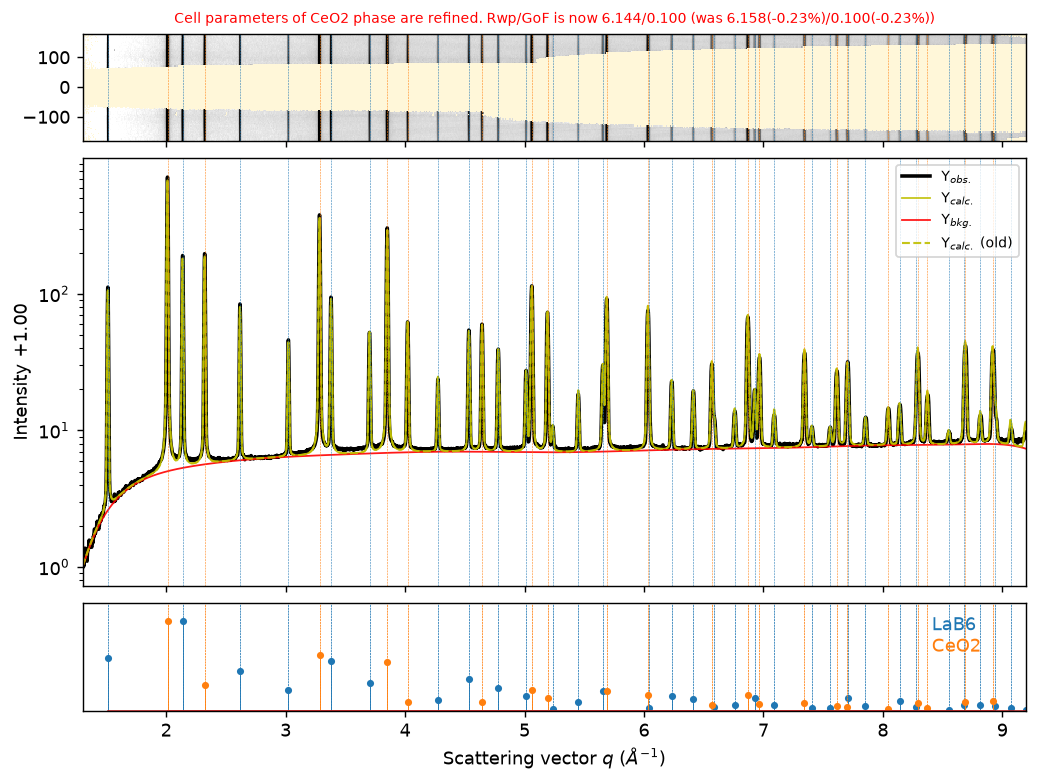

In [32]:
# or , they can be refined one-by-one
sample.refine_cell_parameters(plot=True,phase_ind=0)
sample.refine_cell_parameters(plot=True,phase_ind=1)


 ✅--After setting LeBail refinement to False, Rwp/GoF is now 10.560/0.172 (was 6.144(71.88%)/0.100(71.87%❗))


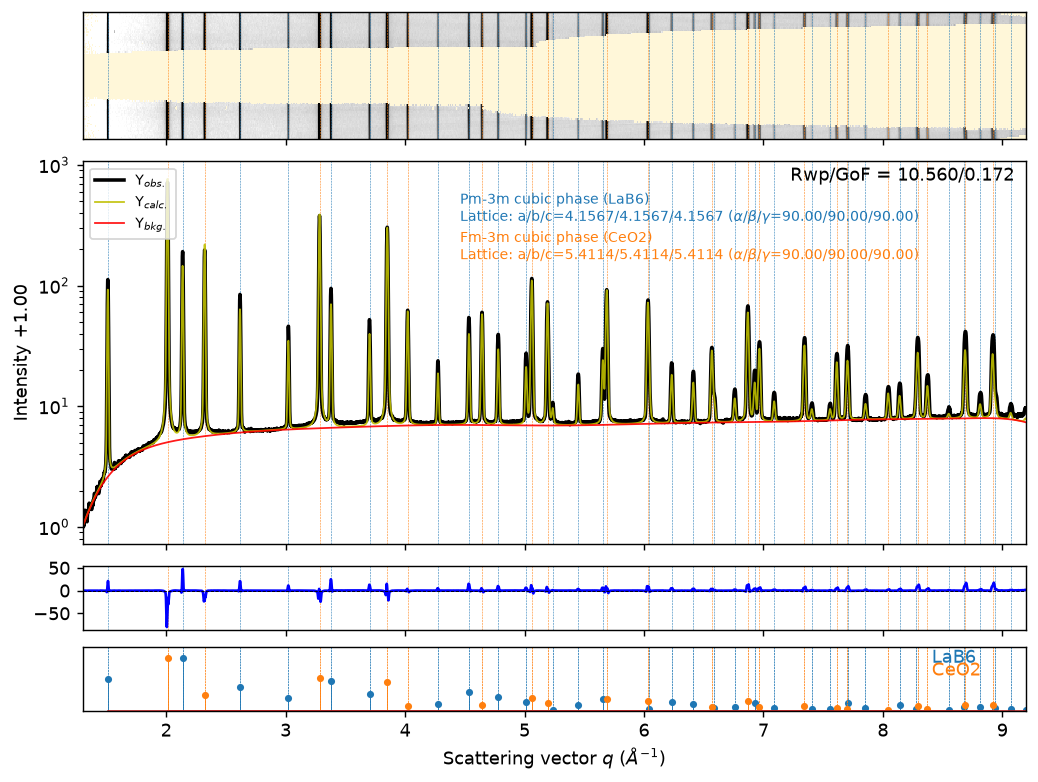

In [33]:
# Now we are enabling Rietveld type refinement.
sample.set_LeBail(to=False, refine=True, plot=False)
sample.plot()

 ✅--Phase fractions of all phases are refined. Rwp/GoF is now 8.952/0.146 (was 10.560(-15.22%)/0.172(-15.22%✨))


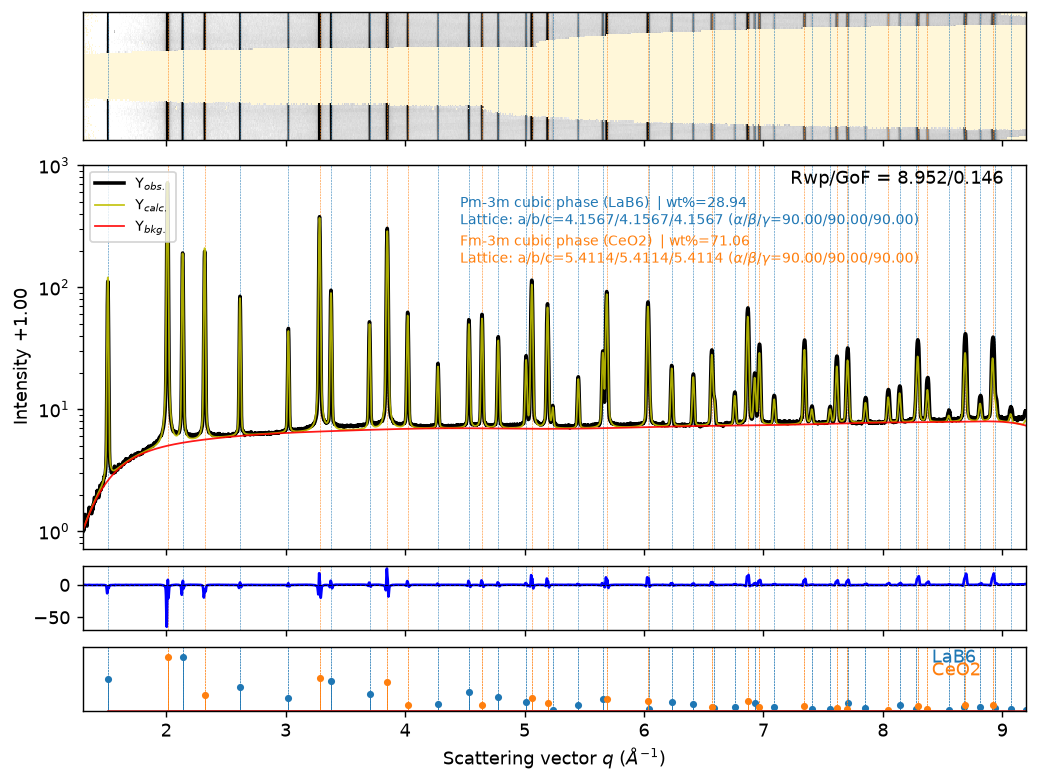

In [34]:
# For samples consisting of multiple phases, we need to refine phase fractions.
sample.refine_phase_fractions()
sample.plot(show_wt_fractions=True)

In [35]:
# Again we need to refine atom properties of CeO2 and LaB6 phases. Note phase_ind here.

sample.refine_site_property(phase_ind=0, site_ind=0,refinement_flags='U',plot=False) # This refines Uiso of La site
sample.refine_site_property(phase_ind=0, site_ind=1,refinement_flags='U',plot=False) # This refines Uiso of La site

sample.refine_site_property(phase_ind=1, site_ind=0,refinement_flags='U',plot=False) # This refines Uiso of Ce site
sample.refine_site_property(phase_ind=1, site_ind=1,refinement_flags='U',plot=False) # This refines Uiso of O site

 ✅--U property of La0 site of LaB6 phase is refined. Rwp/GoF is now 8.695/0.141 (was 8.952(-2.88%)/0.146(-2.88%))


 ✅--U property of B1 site of LaB6 phase is refined. Rwp/GoF is now 8.671/0.141 (was 8.695(-0.27%)/0.141(-0.27%❗))


 ✅--U property of Ce0 site of CeO2 phase is refined. Rwp/GoF is now 6.430/0.105 (was 8.671(-25.84%)/0.141(-25.84%✨))


 ✅--U property of O1 site of CeO2 phase is refined. Rwp/GoF is now 6.398/0.104 (was 6.430(-0.50%)/0.105(-0.50%❗))


 ✅--Background with 15 coeffs is refined. Rwp/GoF is now 6.343/0.103 (was 6.398(-0.87%)/0.104(-0.78%❗))


 ✅--Cell parameters of all phases are refined. Rwp/GoF is now 6.344/0.103 (was 6.343(0.01%)/0.103(-0.07%❗))


 ✅--Phase fractions of all phases are refined. Rwp/GoF is now 6.295/0.102 (was 6.344(-0.77%)/0.103(-0.77%❗))


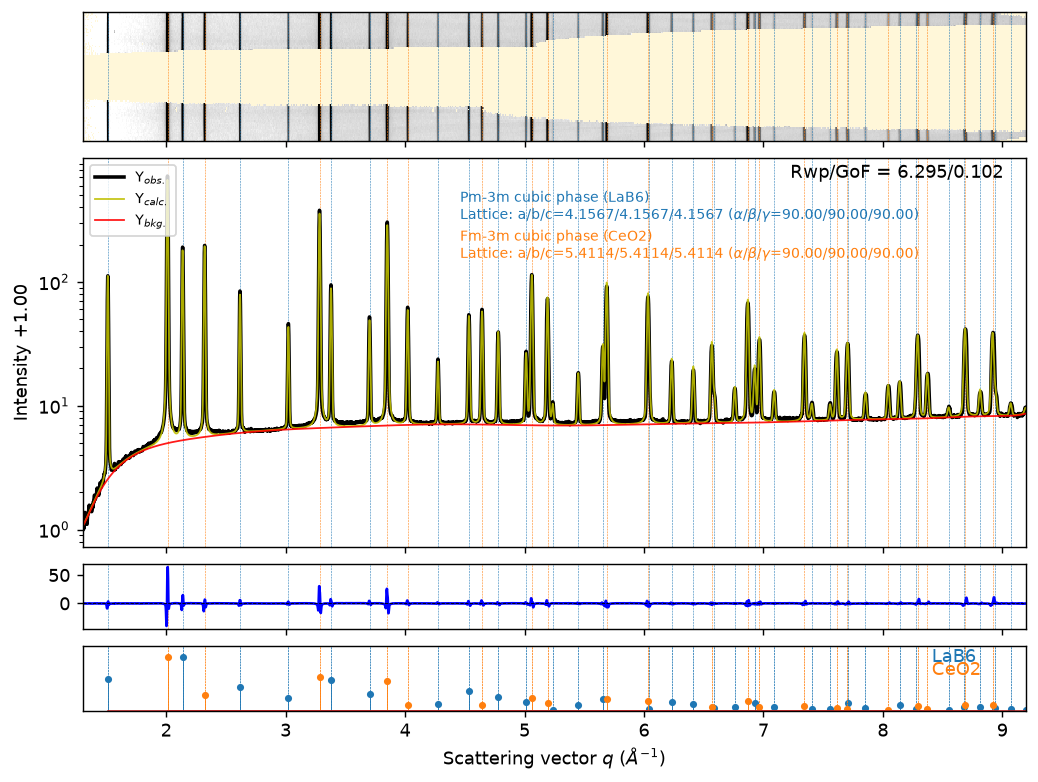

In [36]:
# Re-refine background, cell parameters, and phase fractions simultaneously
sample.refine_background(num_coeffs=15, plot=False)
sample.refine_cell_parameters(plot=False)
sample.refine_phase_fractions(plot=False)

sample.plot()


---
### Navigation

[$\leftarrow$ Previous: 01_basic.ipynb](01_basic.ipynb) | [Next: 03_advanced-part-1.ipynb $\rightarrow$](03_advanced-part-1.ipynb)

In the next notebook, we explore all pre-refinement data loading options, integration parameters, custom baseline methods, and phase caching.